In [1]:
import numpy as np
import xarray as xr
import pandas as pd

import scipy as scipy
from scipy import stats
from scipy.optimize import curve_fit
import math
from scipy.stats import pearsonr, spearmanr, truncnorm
from scipy.stats import gaussian_kde
from sklearn.linear_model import LinearRegression, RANSACRegressor, HuberRegressor, TheilSenRegressor
from sklearn.metrics import mean_squared_error, r2_score

import matplotlib.pyplot as plt
import proplot as plot

from tqdm import tqdm
from datetime import date

import os
import sys
import TEXAS
from TEXAS import load_posterior, generate_ensemble_auto
import cmdstanpy
import cmdstanpy as csp, os, subprocess, sys
print(f"Python Executable: {sys.executable}")
print(f"CmdStanPy Version:   {cmdstanpy.__version__}")
print(f"CmdStanPy Path:      {cmdstanpy.__file__}")
print("cmdstanpy:", csp.__version__)
print("cmdstan_path:", csp.cmdstan_path())
subprocess.run([os.path.join(csp.cmdstan_path(), "bin", "stanc"), "--version"], check=False)

import bayspar as bsr

import importlib
import warnings
warnings.filterwarnings('ignore')


/opt/conda/envs/texas-env/lib/python3.10/site-packages/proplot/__init__.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg


Python Executable: /opt/conda/envs/texas-env/bin/python
CmdStanPy Version:   1.2.5
CmdStanPy Path:      /opt/conda/envs/texas-env/lib/python3.10/site-packages/cmdstanpy/__init__.py
cmdstanpy: 1.2.5
cmdstan_path: /opt/cmdstan/cmdstan-2.36.0
stanc3 v2.36.0 (Unix)


In [2]:
from pathlib import Path
from cmdstanpy import set_cmdstan_path, cmdstan_path

preferred = Path("/opt/cmdstan/cmdstan-2.36.0")
if (preferred / "bin" / "stanc").exists():
    set_cmdstan_path(str(preferred))
    print("Set CMDSTAN ->", cmdstan_path())
else:
    print("Preferred CmdStan not found:", preferred)
    print("Using:", cmdstan_path())


from TEXAS.utils.paths import PROJECT_ROOT, PACKAGE_ROOT, STAN_MODELS_DIR, CMDSTAN_DIR, ONEDRIVE
print(PROJECT_ROOT, PACKAGE_ROOT, STAN_MODELS_DIR, CMDSTAN_DIR, ONEDRIVE)

from cmdstanpy import cmdstan_path
from pathlib import Path


print("CmdStan in use:", cmdstan_path())
print("OneDrive mount exists? ", Path("/mnt/onedrive").exists())


local_github_path = str(PROJECT_ROOT)  # shim for old code
local_onedrive_path = str(ONEDRIVE)

Set CMDSTAN -> /opt/cmdstan/cmdstan-2.36.0
/home/micromamba/app /home/micromamba/app/src/TEXAS /home/micromamba/app/src/TEXAS/stan_models /opt/cmdstan/cmdstan-2.36.0 /mnt/onedrive
CmdStan in use: /opt/cmdstan/cmdstan-2.36.0
OneDrive mount exists?  True


In [3]:
def predictTfromTEX(input_tex,method_name,temptype):
    '''
    
    available methods:
    
    linear: schouten2002, schouten2003, kim2008, OBrien2017
    non-linear: liu2009, kim2010_tex86H
    '''
    
    if temptype not in ['sst','subt']:
        raise ValueError("temptype must be either 'sst' or 'subt'")
    if method_name not in ['schouten2002', 'schouten2003', 'kim2008', 'liu2009', 'kim2010_tex86H', 'OBrien2017']:
        raise ValueError("method_name must be one of the following: 'schouten2002', 'schouten2003', 'kim2008', 'liu2009', 'kim2010_tex86H', 'OBrien2017'")
    
    if temptype=='sst':
        reg_params_dict = {
            'schouten2002':(66.6667,-18.6667),
            'schouten2003':(37.0370,0.5926),
            'kim2008':(56.2000,-10.7800),
            'liu2009':(-16.3000,50.4750),
            'kim2010_tex86H':(68.4,38.6),
            'OBrien2017':(58.8235,-11.1765),
        }
        
        if method_name=='kim2010_tex86H':
            predictor = np.log10(input_tex)
        elif method_name=='liu2009':
            predictor = (1/input_tex)
        elif 'lnTEX' in method_name:
            predictor = np.log(input_tex)
        else:
            predictor = input_tex
        
    slope = reg_params_dict.get(method_name)[0]
    yintercept = reg_params_dict.get(method_name)[1]
    
    predictedT = slope*predictor+yintercept
    return predictedT

def predictTEXfromT(input_sst,method_name,temptype):
    '''
    
    available methods:
    
    linear: schouten2002, schouten2003, kim2008, OBrien2017
    non-linear: liu2009, kim2010_tex86H
    '''
    if temptype not in ['sst','subt']:
        raise ValueError("temptype must be either 'sst' or 'subt'")
    if method_name not in ['schouten2002', 'schouten2003', 'kim2008', 'liu2009', 'kim2010_tex86H', 'OBrien2017']:
        raise ValueError("method_name must be one of the following: 'schouten2002', 'schouten2003', 'kim2008', 'liu2009', 'kim2010_tex86H', 'OBrien2017'")
    if temptype=='sst':    
        reg_params_dict = {
            'schouten2002':(0.015,0.280),
            'schouten2003':(0.027,-0.016),
            'kim2008':(0.017794,0.191815),
            'liu2009':(-16.3000,50.4750),
            'kim2010_tex86H':(68.4,38.6),
            'OBrien2017':(0.0170,0.19),
        }
        
        if 'lnTEX' in method_name:
            predictor = np.log(input_sst)
        else:
            predictor = input_sst
    
    ### calculation
    slope = reg_params_dict.get(method_name)[0]
    yintercept = reg_params_dict.get(method_name)[1]
    if method_name=='liu2009':
        predictedTEX = 1/(slope*predictor+yintercept)
    elif method_name=='kim2010_tex86H':
        predictedTEX = 10**((predictor-yintercept)/slope)
    else:
        predictedTEX = slope*predictor+yintercept
    return predictedTEX

def pred_texRI(x, method_name='zhang16'):
    """
    Predicts the ring index (RI) based on the TEX86 value using the Zhang16 method.
    
    Parameters:
    x (float or array-like): The TEX86 value(s).
    method_name (str): The method to use for prediction. Default is 'zhang16'.
    
    Returns:
    float or array-like: The predicted ring index (RI) value(s).
    """
    if method_name == 'zhang16':
        return -0.77 * x + 3.32 * x**2 + 1.59
    elif method_name == 'linear_thisStudy':
        return 3.1517 * x + 0.5808
    elif method_name == 'exp_thisStudy':
        return np.exp(1.4352 * x + 0.0244)
        
    else:
        raise ValueError(f"Method '{method_name}' is not implemented.")

# Import Data

# Culture-Mesocosm

In [4]:
fpath = f'{local_github_path}/data/spreadsheets'
fname = 'combined_df_culmesocore_griddedRI.csv'
combined_df = pd.read_csv(os.path.join(fpath,fname))
culmeso_df = combined_df[combined_df['datatype']!='coretop'].iloc[:,1:].reset_index(drop=True)
culmeso_df

,SST,scaledRI,TEX86,gdgt23ratio,no3_sf2tc,datatype,fGDGT_0,fGDGT_1,fGDGT_2,fGDGT_3,fGDGT_cren,fGDGT_cren_prime
0,37.0,0.698138,0.578544,0.478873,50.0,culture,0.093972,0.195035,0.060284,0.125887,0.443262,0.081560
1,46.0,0.933659,0.806931,0.482759,50.0,culture,0.005587,0.054469,0.019553,0.040503,0.712291,0.167598
2,18.0,0.609394,0.858108,0.402266,50.0,culture,0.121212,0.101818,0.172121,0.427879,0.161212,0.015758
3,22.0,0.558857,0.827338,1.088785,50.0,culture,0.164571,0.109714,0.266286,0.244571,0.200000,0.014857
4,28.0,0.629379,0.868762,1.064516,50.0,culture,0.118644,0.080226,0.261017,0.245198,0.270056,0.024859
...,...,...,...,...,...,...,...,...,...,...,...,...
95,25.0,0.693123,0.449778,2.629108,50.0,mesocosm,0.230496,0.073897,0.035219,0.013396,0.635200,0.011792
96,32.0,0.656972,0.683519,3.553719,50.0,mesocosm,0.272515,0.051583,0.055801,0.015702,0.564495,0.039904
97,34.0,0.809038,0.606766,2.318038,50.0,mesocosm,0.125782,0.049939,0.045612,0.019677,0.747221,0.011769
98,36.0,0.899697,0.813041,2.396907,50.0,mesocosm,0.049583,0.023916,0.054250,0.022633,0.822493,0.027125


In [5]:
features = ['fGDGT_0', 'fGDGT_1','fGDGT_2', 'fGDGT_3', 'fGDGT_cren', 'fGDGT_cren_prime']
culmeso_df[features].to_csv(f'{local_github_path}/data/spreadsheets/culmeso_fgdgts.csv',index=False)

In [6]:
TEX_models = ['schouten2002','kim2010_tex86H']
for method in TEX_models:
    culmeso_df[f'predTEX_{method}-sst'] = predictTEXfromT(culmeso_df['SST'],method_name=method,temptype='sst')
    culmeso_df[f'predT_{method}-sst'] = predictTfromTEX(culmeso_df['TEX86'],method_name=method,temptype='sst')
    
    culmeso_df[f'TEXres_{method}-sst'] = culmeso_df['TEX86'] - culmeso_df[f'predTEX_{method}-sst']
    culmeso_df[f'Tres_{method}-sst'] = culmeso_df['SST'] - culmeso_df[f'predT_{method}-sst']
    

search_tolerance = np.std(culmeso_df['TEX86'], ddof=1) * 2
results = bsr.predict_seatemp_analog(culmeso_df['TEX86'], temptype='sst',
       prior_mean=30, prior_std=20,search_tol=search_tolerance,nens=200)

culmeso_df[f'predT_BAYSPAR-sst'] = np.percentile(results.ensemble,50,axis=[1,2])
culmeso_df[f'Tres_BAYSPAR-sst'] = culmeso_df[f'SST'] - culmeso_df[f'predT_BAYSPAR-sst']

  0%|          | 0/80 [00:00<?, ?it/s]

100%|██████████| 80/80 [02:02<00:00,  1.53s/it]


In [7]:
Optimal_SST = pd.read_csv(f'{local_github_path}/data/raw/OPTiMAL_culmeso_v2.csv').rename(columns={'GDGT.0':'fGDGT_0',
                                                                                                    ' GDGT.1':'fGDGT_1',
                                                                                                    ' GDGT.2':'fGDGT_2',
                                                                                                    ' GDGT.3':'fGDGT_3',
                                                                                                    ' Crenarchaeol':'fGDGT_cren',
                                                                                                    ' Cren.':'fGDGT_cren_prime',
                                                                                                    ' D_nearest':'D_nearest', 
                                                                                                    ' SST':'optimal_sst'})
culmeso_df.loc[:,'D_nearest'] = Optimal_SST['D_nearest'].values
culmeso_df.loc[:,'optimal_sst'] = Optimal_SST['optimal_sst'].values

culmeso_df

,SST,scaledRI,TEX86,gdgt23ratio,no3_sf2tc,datatype,fGDGT_0,fGDGT_1,fGDGT_2,fGDGT_3,...,TEXres_schouten2002-sst,Tres_schouten2002-sst,predTEX_kim2010_tex86H-sst,predT_kim2010_tex86H-sst,TEXres_kim2010_tex86H-sst,Tres_kim2010_tex86H-sst,predT_BAYSPAR-sst,Tres_BAYSPAR-sst,D_nearest,optimal_sst
0,37.0,0.698138,0.578544,0.478873,50.0,culture,0.093972,0.195035,0.060284,0.125887,...,-0.256456,17.097077,0.947563,22.343812,-0.369019,14.656188,21.678268,15.321732,16.223052,15.535405
1,46.0,0.933659,0.806931,0.482759,50.0,culture,0.005587,0.054469,0.019553,0.040503,...,-0.163069,10.871294,1.282883,32.227598,-0.475953,13.772402,38.634492,7.365508,3.029697,15.664927
2,18.0,0.609394,0.858108,0.402266,50.0,culture,0.121212,0.101818,0.172121,0.427879,...,0.308108,-20.540536,0.499839,34.054273,0.358269,-16.054273,42.517131,-24.517131,79.572533,15.535405
3,22.0,0.558857,0.827338,1.088785,50.0,culture,0.164571,0.109714,0.266286,0.244571,...,0.217338,-14.489203,0.571887,32.969520,0.255452,-10.969520,40.161251,-18.161251,40.851065,15.535405
4,28.0,0.629379,0.868762,1.064516,50.0,culture,0.118644,0.080226,0.261017,0.245198,...,0.168762,-11.250766,0.699889,34.420801,0.168872,-6.420801,43.350407,-15.350407,40.927695,15.535405
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,25.0,0.693123,0.449778,2.629108,50.0,mesocosm,0.230496,0.073897,0.035219,0.013396,...,-0.205222,13.681514,0.632659,14.865049,-0.182881,10.134951,11.912933,13.087067,0.704603,16.223608
96,32.0,0.656972,0.683519,3.553719,50.0,mesocosm,0.272515,0.051583,0.055801,0.015702,...,-0.076481,5.098737,0.800772,27.296945,-0.117253,4.703055,29.420214,2.579786,0.508515,24.194715
97,34.0,0.809038,0.606766,2.318038,50.0,mesocosm,0.125782,0.049939,0.045612,0.019677,...,-0.183234,12.215589,0.856542,23.758670,-0.249775,10.241330,23.794033,10.205967,1.015926,23.318223
98,36.0,0.899697,0.813041,2.396907,50.0,mesocosm,0.049583,0.023916,0.054250,0.022633,...,-0.006959,0.463906,0.916196,32.451709,-0.103154,3.548291,39.083207,-3.083207,1.527550,18.864307


In [8]:
sel_temp_param = 'SST'
temptype = 'sst'
fwd_posterior_list = [
    f'hier_crtp_univ_priorApprox_{temptype}',
    f'gen_logi_fixed_hier_crtp_univ_priorApprox_{temptype}',
    f'gen_logi_fixed_hier_crtp_univ_priorApprox_{temptype}_test01_cln_crtp',
    f'hier_crtp_multiv_{temptype}_gdgt23ratio',
    f'gen_logi_fixed_hier_crtp_multiv_priorApprox_{temptype}_gdgt23ratio',
    f'gen_logi_fixed_hier_crtp_multiv_priorApprox_{temptype}_gdgt23ratio_test01_cln_crtp',
    f'hier_crtp_multiv_{temptype}_gdgt23ratio_no3_1.5',
    f'gen_logi_fixed_hier_crtp_multiv_priorApprox_{temptype}_gdgt23ratio_no3_1.5',
    f'gen_logi_fixed_hier_crtp_multiv_priorApprox_{temptype}_gdgt23ratio_no3_1.5_test01_cln_crtp',  
]

new_col_names = [
    f'predT_sim_logi_T-{temptype}_marginal_unconstrained',
    f'predT_T-{temptype}_marginal_unconstrained',
    f'predT_T-{temptype}_new_marginal_unconstrained',
    f'predT_sim_logi_T-{temptype}-g23r_marginal_unconstrained',
    f'predT_T-{temptype}-g23r_marginal_unconstrained',
    f'predT_T-{temptype}-g23r_new_marginal_unconstrained',
    f'predT_sim_logi_T-{temptype}-g23r-no3_marginal_unconstrained',
    f'predT_T-{temptype}-g23r-no3_marginal_unconstrained',
    f'predT_T-{temptype}-g23r-no3_new_marginal_unconstrained',
]

filename_tag_list = [
    '',
    '',
    'test01',
    '',
    '',
    'test01',
    '',
    '',
    'test01',
]

for i, (fwd_posterior_name, col_name, filename_tag) in enumerate(zip(fwd_posterior_list, new_col_names, filename_tag_list)):
    
    if 'no3' in fwd_posterior_name:
        nonnan_idx = (pd.notna(culmeso_df['scaledRI']) &
                      pd.notna(culmeso_df[sel_temp_param]) &
                      pd.notna(culmeso_df['gdgt23ratio']) &
                      pd.notna(culmeso_df['no3_sf2tc']))
    elif 'gdgt23ratio' in fwd_posterior_name:
        nonnan_idx = (pd.notna(culmeso_df['scaledRI']) &
                      pd.notna(culmeso_df[sel_temp_param]) &
                      pd.notna(culmeso_df['gdgt23ratio']))
    else:
        nonnan_idx = pd.notna(culmeso_df['scaledRI']) & pd.notna(culmeso_df[sel_temp_param])
    
    print(f"Found {nonnan_idx.sum()} valid rows out of {len(culmeso_df)}")
    print(f"Running {fwd_posterior_name} with tag: {filename_tag}")
    
    results_dict = TEXAS.stan.predict_temperature_from_RI(
        scaledRI=culmeso_df.loc[nonnan_idx, 'scaledRI'].astype(float).tolist(),
        prior_mu_t=culmeso_df.loc[nonnan_idx, sel_temp_param].values,
        prior_sigma_t=6,
        fwd_posterior_name=fwd_posterior_name,
        site_name='global-coretop',
        temptype=temptype,
        chains=2,
        iter_warmup=200,
        iter_sampling=500,
        save_results=True,
        filename_tag=filename_tag,  
        predictors={
                'gdgt23ratio': culmeso_df.loc[nonnan_idx, 'gdgt23ratio'].values,
            },
        threads_per_chain=4,
        constraint_type='hard_constraint',
        min_temp=-1.8
    )
    culmeso_df.loc[nonnan_idx, col_name] = results_dict['p50']

Found 100 valid rows out of 100
Running hier_crtp_univ_priorApprox_sst with tag: 


07:56:56 - cmdstanpy - INFO - CmdStan start processing


🔧 Automatically selected Stan file: invT_logistic_fixed_univ_marginal_hard_constraint.stan
| M=100 N=100
🔧 Compiling Stan model: invT_logistic_fixed_univ_marginal_hard_constraint.stan
✅ Compiled: invT_logistic_fixed_univ_marginal_hard_constraint.stan
Starting Stan sampling with 100 observations...


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

...

✅ Posterior saved to /home/micromamba/app/data/cache/TEXAS_invT_posterior_cache/global-coretop_invT_gen_logi_fixed_multiv_hard_constraint_sst_gdgt23ratio_no3_0.0_direct.nc
✅ invT results saved: /home/micromamba/app/data/cache/TEXAS_invT_posterior_cache/global-coretop_invT_gen_logi_fixed_multiv_hard_constraint_sst_gdgt23ratio_no3_0.0_direct.npz
Found 100 valid rows out of 100
Running gen_logi_fixed_hier_crtp_multiv_priorApprox_sst_gdgt23ratio_no3_1.5_test01_cln_crtp with tag: test01
🔧 Automatically selected Stan file: invT_gen_logi_fixed_multiv_marginal_hard_constraint.stan
| M=100 N=100
Starting Stan sampling with 100 observations...


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

08:01:37 - cmdstanpy - INFO - CmdStan done processing.



✅ Stan sampling completed successfully
✅ Posterior saved to /home/micromamba/app/data/cache/TEXAS_invT_posterior_cache/global-coretop_invT_gen_logi_fixed_multiv_hard_constraint_sst_gdgt23ratio_no3_0.0_test01_direct.nc
✅ invT results saved: /home/micromamba/app/data/cache/TEXAS_invT_posterior_cache/global-coretop_invT_gen_logi_fixed_multiv_hard_constraint_sst_gdgt23ratio_no3_0.0_test01_direct.npz


In [9]:
temptype = 'sst'
fwd_posterior_list = [
    f'hier_crtp_univ_priorApprox_{temptype}',
    f'gen_logi_fixed_hier_crtp_univ_priorApprox_{temptype}',
    f'gen_logi_fixed_hier_crtp_univ_priorApprox_{temptype}_test01_cln_crtp',
    f'hier_crtp_multiv_{temptype}_gdgt23ratio',
    f'gen_logi_fixed_hier_crtp_multiv_priorApprox_{temptype}_gdgt23ratio',
    f'gen_logi_fixed_hier_crtp_multiv_priorApprox_{temptype}_gdgt23ratio_test01_cln_crtp',
    f'hier_crtp_multiv_{temptype}_gdgt23ratio_no3_1.5',
    f'gen_logi_fixed_hier_crtp_multiv_priorApprox_{temptype}_gdgt23ratio_no3_1.5',
    f'gen_logi_fixed_hier_crtp_multiv_priorApprox_{temptype}_gdgt23ratio_no3_1.5_test01_cln_crtp',
    
]


new_col_names = [
    f'sim_logi_T-{temptype}',
    f'T-{temptype}',
    f'T-{temptype}_new',
    f'sim_logi_T-{temptype}-g23r',
    f'T-{temptype}-g23r',
    f'T-{temptype}-g23r_new',
    f'sim_logi_T-{temptype}-g23r-no3',
    f'T-{temptype}-g23r-no3',
    f'T-{temptype}-g23r-no3_new',
]


for post_ds, new_name in zip(fwd_posterior_list, new_col_names):
    culmeso_df[f'predRI_{new_name}'] = generate_ensemble_auto(
                load_posterior(post_ds),
                x_vals = culmeso_df['SST'],
                gdgt23ratio = culmeso_df['gdgt23ratio'])['p50']
    
    

In [10]:
sel_temp_param = 'SST'
temptype = 'thermoT'
fwd_posterior_list = [
    f'hier_crtp_univ_priorApprox_{temptype}',
    f'gen_logi_fixed_hier_crtp_univ_priorApprox_{temptype}',
    f'gen_logi_fixed_hier_crtp_univ_priorApprox_{temptype}_test01_cln_crtp',
    f'hier_crtp_multiv_{temptype}_gdgt23ratio',
    f'gen_logi_fixed_hier_crtp_multiv_priorApprox_{temptype}_gdgt23ratio',
    f'gen_logi_fixed_hier_crtp_multiv_priorApprox_{temptype}_gdgt23ratio_test01_cln_crtp',
    f'hier_crtp_multiv_{temptype}_gdgt23ratio_no3_1.5',
    f'gen_logi_fixed_hier_crtp_multiv_priorApprox_{temptype}_gdgt23ratio_no3_1.5',
    f'gen_logi_fixed_hier_crtp_multiv_priorApprox_{temptype}_gdgt23ratio_no3_1.5_test01_cln_crtp',  
]

new_col_names = [
    f'predT_sim_logi_T-{temptype}_marginal_unconstrained',
    f'predT_T-{temptype}_marginal_unconstrained',
    f'predT_T-{temptype}_new_marginal_unconstrained',
    f'predT_sim_logi_T-{temptype}-g23r_marginal_unconstrained',
    f'predT_T-{temptype}-g23r_marginal_unconstrained',
    f'predT_T-{temptype}-g23r_new_marginal_unconstrained',
    f'predT_sim_logi_T-{temptype}-g23r-no3_marginal_unconstrained',
    f'predT_T-{temptype}-g23r-no3_marginal_unconstrained',
    f'predT_T-{temptype}-g23r-no3_new_marginal_unconstrained',
]

filename_tag_list = [
    '',
    '',
    'test01',
    '',
    '',
    'test01',
    '',
    '',
    'test01',
]


for i, (fwd_posterior_name, col_name, filename_tag) in enumerate(zip(fwd_posterior_list, new_col_names, filename_tag_list)):
    
    if 'no3' in fwd_posterior_name:
        nonnan_idx = (pd.notna(culmeso_df['scaledRI']) &
                      pd.notna(culmeso_df[sel_temp_param]) &
                      pd.notna(culmeso_df['gdgt23ratio']) &
                      pd.notna(culmeso_df['no3_sf2tc']))
    elif 'gdgt23ratio' in fwd_posterior_name:
        nonnan_idx = (pd.notna(culmeso_df['scaledRI']) &
                      pd.notna(culmeso_df[sel_temp_param]) &
                      pd.notna(culmeso_df['gdgt23ratio']))
    else:
        nonnan_idx = pd.notna(culmeso_df['scaledRI']) & pd.notna(culmeso_df[sel_temp_param])
    
    print(f"Found {nonnan_idx.sum()} valid rows out of {len(culmeso_df)}")
    print(f"Running {fwd_posterior_name} with tag: {filename_tag}")
    
    results_dict = TEXAS.stan.predict_temperature_from_RI(
        scaledRI=culmeso_df.loc[nonnan_idx, 'scaledRI'].astype(float).tolist(),
        prior_mu_t=culmeso_df.loc[nonnan_idx, sel_temp_param].values,
        prior_sigma_t=6,
        fwd_posterior_name=fwd_posterior_name,
        site_name='global-coretop',
        temptype=temptype,
        chains=2,
        iter_warmup=200,
        iter_sampling=500,
        save_results=True,
        filename_tag=filename_tag,  
        predictors={
                'gdgt23ratio': culmeso_df.loc[nonnan_idx, 'gdgt23ratio'].values,
            },
        threads_per_chain=4,
    )
    culmeso_df.loc[nonnan_idx, col_name] = results_dict['p50']

08:01:38 - cmdstanpy - INFO - CmdStan start processing


Found 100 valid rows out of 100
Running hier_crtp_univ_priorApprox_thermoT with tag: 
🔧 Automatically selected Stan file: invT_logistic_fixed_univ_marginal_unconstrained.stan
| M=100 N=100
🔧 Compiling Stan model: invT_logistic_fixed_univ_marginal_unconstrained.stan
✅ Compiled: invT_logistic_fixed_univ_marginal_unconstrained.stan
Starting Stan sampling with 100 observations...


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

08:02:01 - cmdstanpy - INFO - CmdStan done processing.


...

✅ Posterior saved to /home/micromamba/app/data/cache/TEXAS_invT_posterior_cache/global-coretop_invT_gen_logi_fixed_multiv_unconstrained_thermoT_gdgt23ratio_no3_0.0_direct.nc
✅ invT results saved: /home/micromamba/app/data/cache/TEXAS_invT_posterior_cache/global-coretop_invT_gen_logi_fixed_multiv_unconstrained_thermoT_gdgt23ratio_no3_0.0_direct.npz
Found 100 valid rows out of 100
Running gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio_no3_1.5_test01_cln_crtp with tag: test01
🔧 Automatically selected Stan file: invT_gen_logi_fixed_multiv_marginal_unconstrained.stan
| M=100 N=100
Starting Stan sampling with 100 observations...


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

08:04:18 - cmdstanpy - INFO - CmdStan done processing.



✅ Stan sampling completed successfully
✅ Posterior saved to /home/micromamba/app/data/cache/TEXAS_invT_posterior_cache/global-coretop_invT_gen_logi_fixed_multiv_unconstrained_thermoT_gdgt23ratio_no3_0.0_test01_direct.nc
✅ invT results saved: /home/micromamba/app/data/cache/TEXAS_invT_posterior_cache/global-coretop_invT_gen_logi_fixed_multiv_unconstrained_thermoT_gdgt23ratio_no3_0.0_test01_direct.npz


In [11]:
temptype = 'thermoT'
fwd_posterior_list = [
    f'hier_crtp_univ_priorApprox_{temptype}',
    f'gen_logi_fixed_hier_crtp_univ_priorApprox_{temptype}',
    f'gen_logi_fixed_hier_crtp_univ_priorApprox_{temptype}_test01_cln_crtp',
    f'hier_crtp_multiv_{temptype}_gdgt23ratio',
    f'gen_logi_fixed_hier_crtp_multiv_priorApprox_{temptype}_gdgt23ratio',
    f'gen_logi_fixed_hier_crtp_multiv_priorApprox_{temptype}_gdgt23ratio_test01_cln_crtp',
    f'hier_crtp_multiv_{temptype}_gdgt23ratio_no3_1.5',
    f'gen_logi_fixed_hier_crtp_multiv_priorApprox_{temptype}_gdgt23ratio_no3_1.5',
    f'gen_logi_fixed_hier_crtp_multiv_priorApprox_{temptype}_gdgt23ratio_no3_1.5_test01_cln_crtp',
    
]


new_col_names = [
    f'sim_logi_T-{temptype}',
    f'T-{temptype}',
    f'T-{temptype}_new',
    f'sim_logi_T-{temptype}-g23r',
    f'T-{temptype}-g23r',
    f'T-{temptype}-g23r_new',
    f'sim_logi_T-{temptype}-g23r-no3',
    f'T-{temptype}-g23r-no3',
    f'T-{temptype}-g23r-no3_new',
]


for post_ds, new_name in zip(fwd_posterior_list, new_col_names):
    culmeso_df[f'predRI_{new_name}'] = generate_ensemble_auto(
                load_posterior(post_ds),
                x_vals = culmeso_df['SST'],
                gdgt23ratio = culmeso_df['gdgt23ratio'])['p50']
    
    

In [12]:
culmeso_df

,SST,scaledRI,TEX86,gdgt23ratio,no3_sf2tc,datatype,fGDGT_0,fGDGT_1,fGDGT_2,fGDGT_3,...,predT_T-thermoT-g23r-no3_new_marginal_unconstrained,predRI_sim_logi_T-thermoT,predRI_T-thermoT,predRI_T-thermoT_new,predRI_sim_logi_T-thermoT-g23r,predRI_T-thermoT-g23r,predRI_T-thermoT-g23r_new,predRI_sim_logi_T-thermoT-g23r-no3,predRI_T-thermoT-g23r-no3,predRI_T-thermoT-g23r-no3_new
0,37.0,0.698138,0.578544,0.478873,50.0,culture,0.093972,0.195035,0.060284,0.125887,...,27.92000,0.870262,0.926399,0.930154,0.881394,0.924332,0.928656,0.862153,0.904342,0.899151
1,46.0,0.933659,0.806931,0.482759,50.0,culture,0.005587,0.054469,0.019553,0.040503,...,44.67455,0.954770,0.992001,0.992554,0.955220,0.986671,0.987952,0.944177,0.981109,0.979080
2,18.0,0.609394,0.858108,0.402266,50.0,culture,0.121212,0.101818,0.172121,0.427879,...,19.60950,0.551131,0.549409,0.550862,0.584771,0.583189,0.582415,0.576874,0.575397,0.572312
3,22.0,0.558857,0.827338,1.088785,50.0,culture,0.164571,0.109714,0.266286,0.244571,...,18.22295,0.607302,0.603398,0.605603,0.638172,0.634623,0.634633,0.625555,0.622769,0.619145
4,28.0,0.629379,0.868762,1.064516,50.0,culture,0.118644,0.080226,0.261017,0.245198,...,23.37460,0.715264,0.723632,0.727836,0.740910,0.748026,0.750232,0.721391,0.727570,0.722892
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,25.0,0.693123,0.449778,2.629108,50.0,mesocosm,0.230496,0.073897,0.035219,0.013396,...,26.40875,0.658985,0.657467,0.660390,0.679868,0.678655,0.680023,0.663396,0.662526,0.659372
96,32.0,0.656972,0.683519,3.553719,50.0,mesocosm,0.272515,0.051583,0.055801,0.015702,...,26.04445,0.790382,0.822830,0.827492,0.794882,0.820595,0.825246,0.773949,0.796590,0.792414
97,34.0,0.809038,0.606766,2.318038,50.0,mesocosm,0.125782,0.049939,0.045612,0.019677,...,32.85355,0.824975,0.869681,0.874632,0.831881,0.866741,0.871416,0.811127,0.843001,0.838079
98,36.0,0.899697,0.813041,2.396907,50.0,mesocosm,0.049583,0.023916,0.054250,0.022633,...,37.94305,0.856120,0.909639,0.913858,0.858707,0.899814,0.904450,0.838940,0.878531,0.873747


In [13]:
culmeso_df = culmeso_df.rename(columns={'optimal_sst':'predT_OPTiMAL-sst'})

predT_features = culmeso_df.columns[culmeso_df.columns.str.contains('predT_')]
for feature in predT_features:
    colname = feature.replace('predT_','Tres_')
    culmeso_df.loc[:,colname] = culmeso_df['SST'] - culmeso_df[feature]
    
predRI_features = culmeso_df.columns[culmeso_df.columns.str.contains('predRI_')]
for feature in predT_features:
    colname = feature.replace('predRI_','RIres_')
    culmeso_df.loc[:,colname] = culmeso_df['SST'] - culmeso_df[feature]

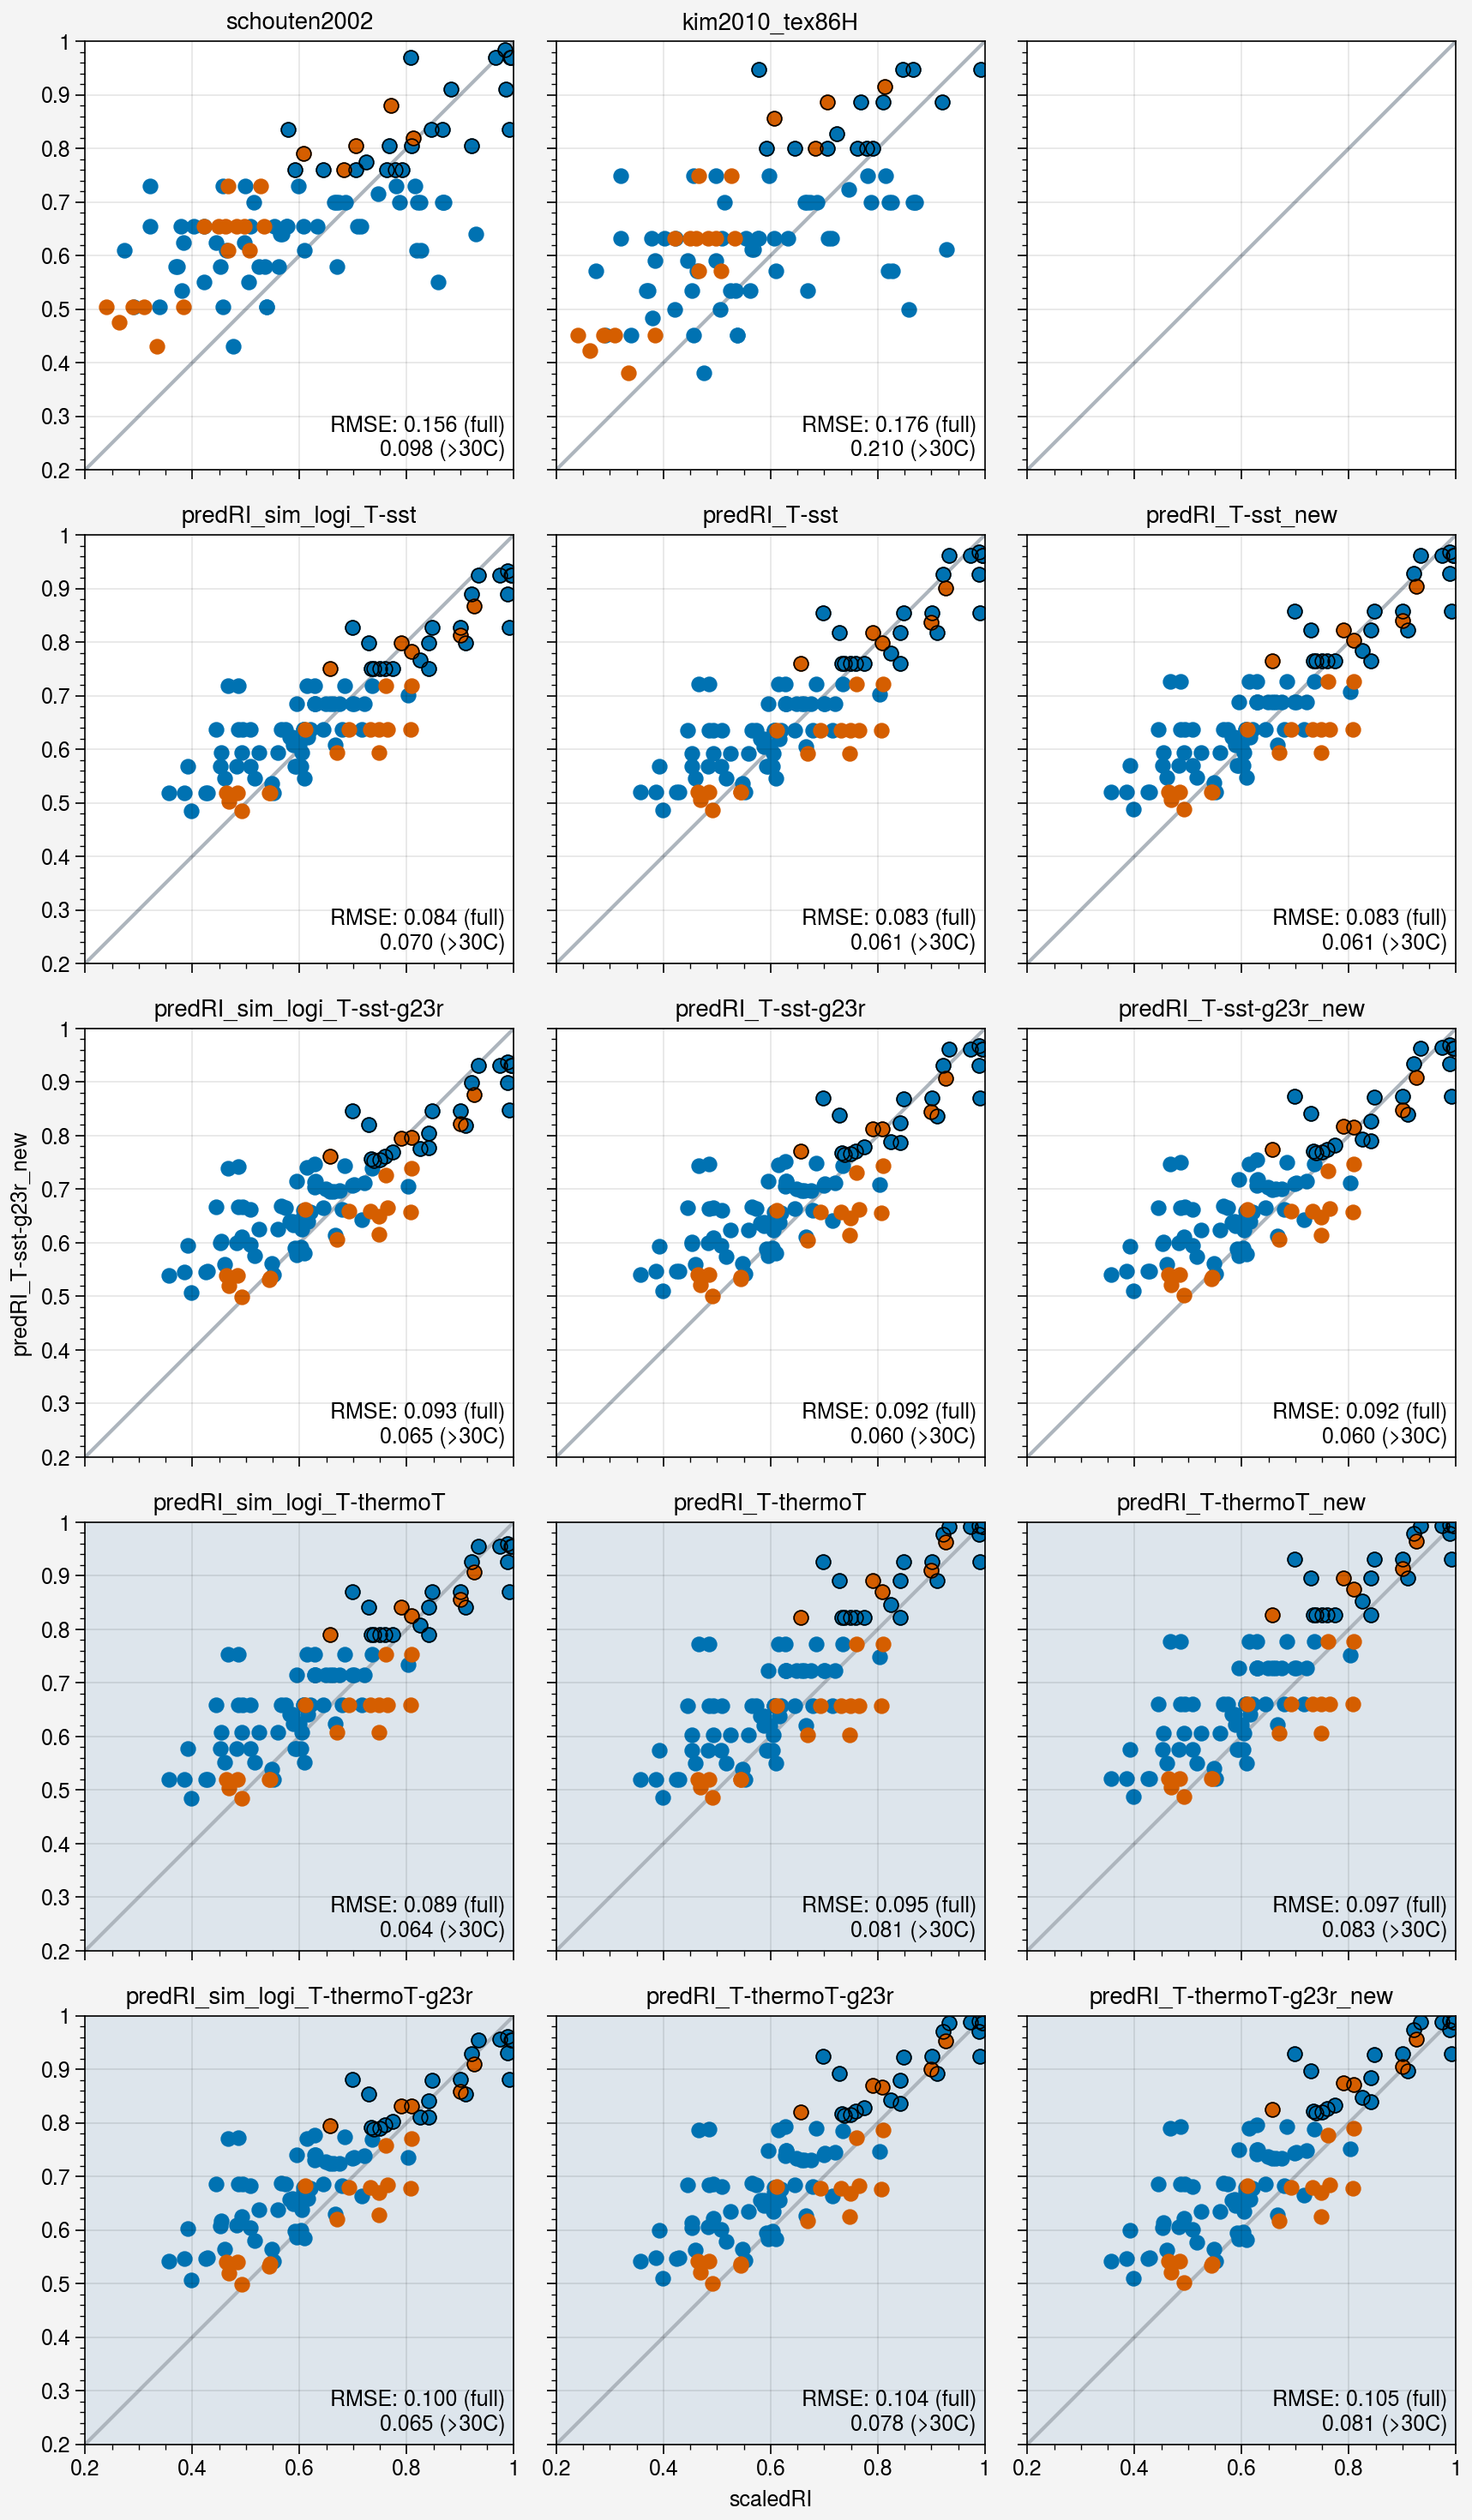

In [14]:
from matplotlib.patches import Rectangle

fig, axs = plot.subplots(ncols=3,nrows=5)
methods = ['schouten2002','kim2010_tex86H','BAYSPAR']
temptype = 'sst'

x_param = 'TEX86'
for i, method in enumerate(methods):
    y_param = f'predTEX_{method}-{temptype}'
    ax = axs[0,i]
    if method != 'BAYSPAR':
        grouped = culmeso_df.groupby('datatype')
        for name, group in grouped:
            plot_x = group[x_param]
            plot_y = group[y_param]
            ax.scatter(plot_x,plot_y)
        
        ### RMSE for total dataset
        reg_data = culmeso_df
        nonnan_idx = ~reg_data[x_param].isnull() & ~reg_data[y_param].isnull()
        
        rmse_ = np.sqrt(mean_squared_error(reg_data[x_param][nonnan_idx],reg_data[y_param][nonnan_idx]))
        
        above_30 = reg_data['SST'] > 30
        rmse_above30_ = np.sqrt(mean_squared_error(reg_data[x_param][nonnan_idx][above_30],reg_data[y_param][nonnan_idx][above_30]))
        
        ax.scatter(reg_data[x_param][above_30],reg_data[y_param][above_30],facecolor='none',mec='k')
        
        ax.text(0.98,0.02,f'RMSE: {rmse_:.3f} (full)\n{rmse_above30_:.3f} (>30C)',transform=ax.transAxes,
                ha='right',va='bottom')
        ax.format(
            title=f'{method}',
        )
        
        if method == 'BAYSPAR':
            ax.format(ultitle='analog mode\nprior_mu_t = 30\nstd = 20')
        
    rect = Rectangle((30,30),30,30,facecolor='gray5',alpha=0.5,zorder=0)
    ax.add_patch(rect)
#################################################################################
x_param = 'scaledRI'
features = ['predRI_sim_logi_T-sst','predRI_T-sst', 'predRI_T-sst_new']
for i, feature in enumerate(features):
    ax = axs[1,i]
    grouped = culmeso_df.groupby('datatype')
    for name, group in grouped:
        plot_x = group[x_param]
        plot_y = group[feature]
        ax.scatter(plot_x,plot_y)
    ### RMSE for total dataset
    reg_data = culmeso_df
    nonnan_idx = ~reg_data[x_param].isnull() & ~reg_data[feature].isnull()
    
    rmse_ = np.sqrt(mean_squared_error(reg_data[x_param][nonnan_idx],reg_data[feature][nonnan_idx]))
    
    above_30 = reg_data['SST'] > 30
    rmse_above30_ = np.sqrt(mean_squared_error(reg_data[x_param][nonnan_idx][above_30],reg_data[feature][nonnan_idx][above_30]))
    ax.scatter(reg_data[x_param][above_30],reg_data[feature][above_30],facecolor='none',mec='k')
    ax.text(0.98,0.02,f'RMSE: {rmse_:.3f} (full)\n{rmse_above30_:.3f} (>30C)',transform=ax.transAxes,
            ha='right',va='bottom')
    ax.format(
        title=feature.replace('predT_',''),
    )
    
features = ['predRI_sim_logi_T-sst-g23r','predRI_T-sst-g23r', 'predRI_T-sst-g23r_new']
for i, feature in enumerate(features):
    ax = axs[2,i]
    grouped = culmeso_df.groupby('datatype')
    for name, group in grouped:
        plot_x = group[x_param]
        plot_y = group[feature]
        ax.scatter(plot_x,plot_y)
    ### RMSE for total dataset
    reg_data = culmeso_df
    nonnan_idx = ~reg_data[x_param].isnull() & ~reg_data[feature].isnull()
    
    rmse_ = np.sqrt(mean_squared_error(reg_data[x_param][nonnan_idx],reg_data[feature][nonnan_idx]))
    
    above_30 = reg_data['SST'] > 30
    rmse_above30_ = np.sqrt(mean_squared_error(reg_data[x_param][nonnan_idx][above_30],reg_data[feature][nonnan_idx][above_30]))
    ax.scatter(reg_data[x_param][above_30],reg_data[feature][above_30],facecolor='none',mec='k')
    ax.text(0.98,0.02,f'RMSE: {rmse_:.3f} (full)\n{rmse_above30_:.3f} (>30C)',transform=ax.transAxes,
            ha='right',va='bottom')
    ax.format(
        title=feature.replace('predT_',''),
    )
#################################################################################
x_param = 'scaledRI' 
features = ['predRI_sim_logi_T-thermoT','predRI_T-thermoT', 'predRI_T-thermoT_new']
for i, feature in enumerate(features):
    ax = axs[3,i]
    grouped = culmeso_df.groupby('datatype')
    for name, group in grouped:
        plot_x = group[x_param]
        plot_y = group[feature]
        ax.scatter(plot_x,plot_y)
    ### RMSE for total dataset
    reg_data = culmeso_df
    nonnan_idx = ~reg_data[x_param].isnull() & ~reg_data[feature].isnull()
    
    rmse_ = np.sqrt(mean_squared_error(reg_data[x_param][nonnan_idx],reg_data[feature][nonnan_idx]))
    
    above_30 = reg_data['SST'] > 30
    rmse_above30_ = np.sqrt(mean_squared_error(reg_data[x_param][nonnan_idx][above_30],reg_data[feature][nonnan_idx][above_30]))
    ax.scatter(reg_data[x_param][above_30],reg_data[feature][above_30],facecolor='none',mec='k')
    ax.text(0.98,0.02,f'RMSE: {rmse_:.3f} (full)\n{rmse_above30_:.3f} (>30C)',transform=ax.transAxes,
            ha='right',va='bottom')
    ax.format(
        title=feature.replace('predT_',''),
    )
    
features = ['predRI_sim_logi_T-thermoT-g23r','predRI_T-thermoT-g23r', 'predRI_T-thermoT-g23r_new']
for i, feature in enumerate(features):
    ax = axs[4,i]
    grouped = culmeso_df.groupby('datatype')
    for name, group in grouped:
        plot_x = group[x_param]
        plot_y = group[feature]
        ax.scatter(plot_x,plot_y)
    ### RMSE for total dataset
    reg_data = culmeso_df
    nonnan_idx = ~reg_data[x_param].isnull() & ~reg_data[feature].isnull()
    
    rmse_ = np.sqrt(mean_squared_error(reg_data[x_param][nonnan_idx],reg_data[feature][nonnan_idx]))
    
    above_30 = reg_data['SST'] > 30
    rmse_above30_ = np.sqrt(mean_squared_error(reg_data[x_param][nonnan_idx][above_30],reg_data[feature][nonnan_idx][above_30]))
    ax.scatter(reg_data[x_param][above_30],reg_data[feature][above_30],facecolor='none',mec='k')
    ax.text(0.98,0.02,f'RMSE: {rmse_:.3f} (full)\n{rmse_above30_:.3f} (>30C)',transform=ax.transAxes,
            ha='right',va='bottom')
    ax.format(
        title=feature.replace('predT_',''),
    )
    
    
axs.format(xlim=(0.2,1),ylim=(0.2,1))
axs.plot([0,1],[0,1],c='gray5',zorder=0)
axs[3:,:].format(facecolor='blue9',alpha=0.1)
plt.show()


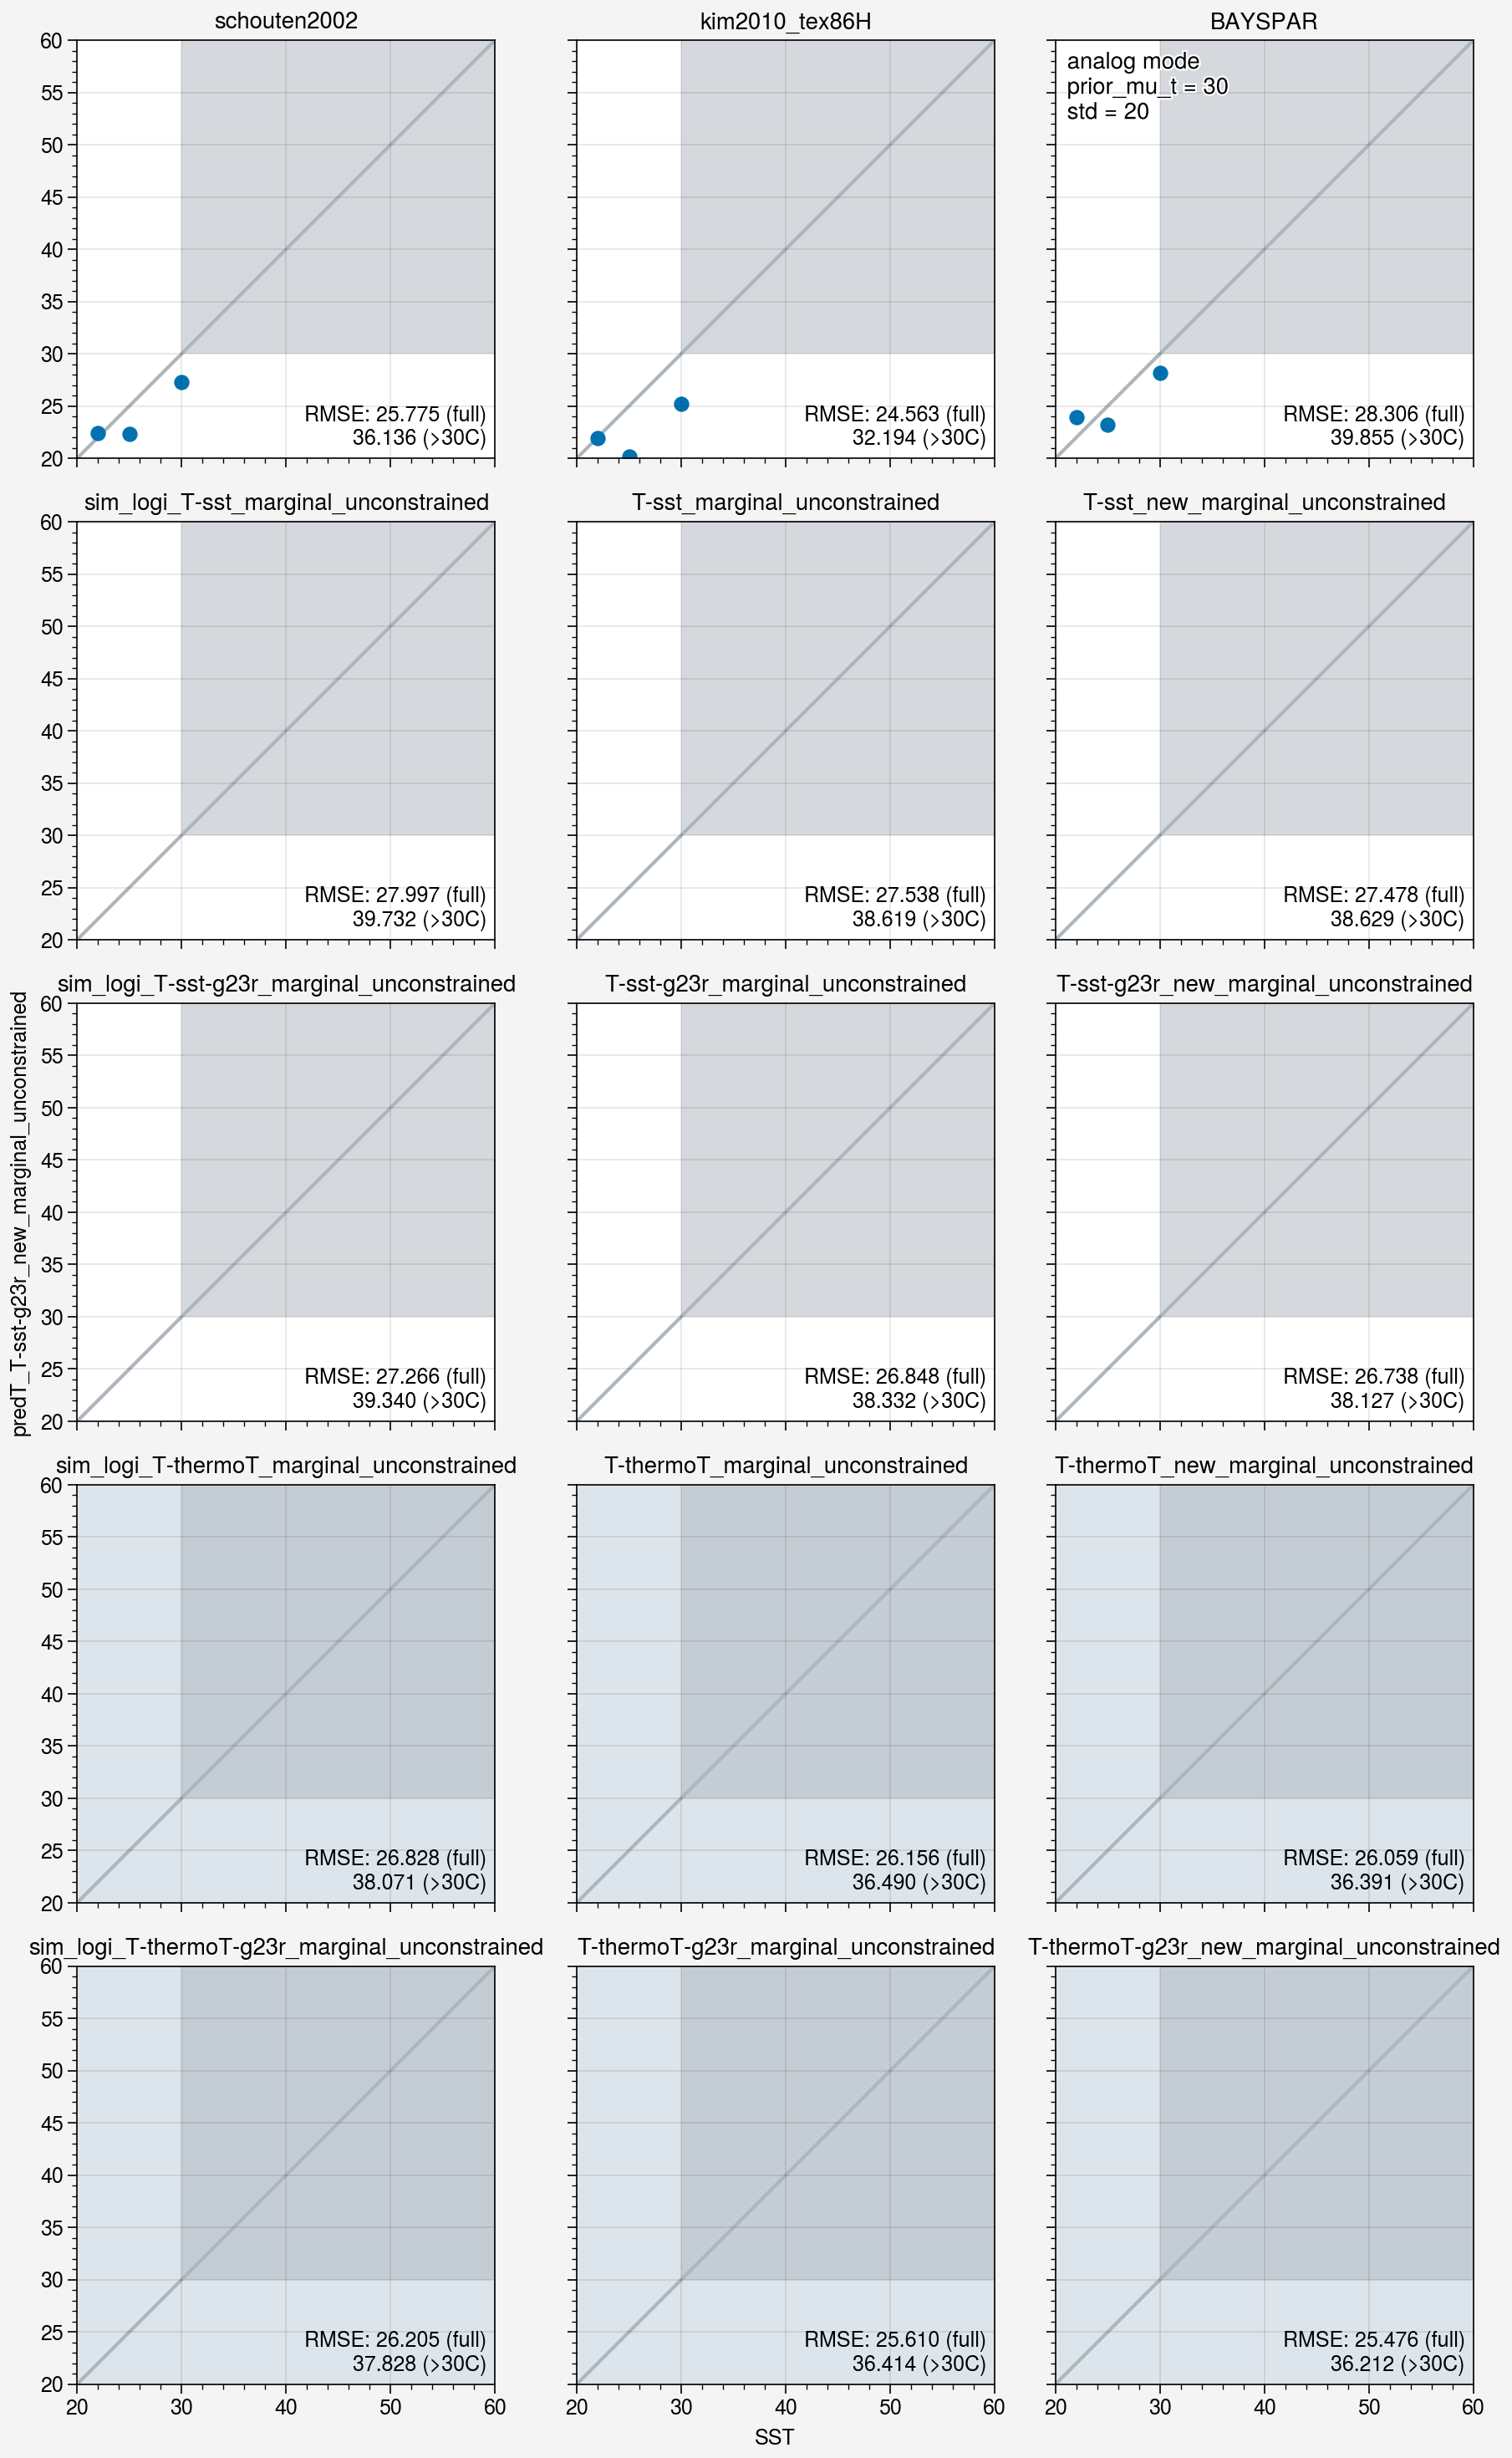

In [15]:
from matplotlib.patches import Rectangle

fig, axs = plot.subplots(ncols=3,nrows=5)
methods = ['schouten2002','kim2010_tex86H','BAYSPAR']
temptype = 'sst'
for i, method in enumerate(methods):
    ax = axs[0,i]
    grouped = culmeso_df.groupby('datatype')
    for name, group in grouped:
        plot_x = group['SST']
        plot_y = group[f'predT_{method}-{temptype}']
        ax.scatter(plot_x,plot_y)
    
    ### RMSE for total dataset
    reg_data = culmeso_df
    nonnan_idx = ~reg_data['SST'].isnull() & ~reg_data[f'predT_{method}-{temptype}'].isnull()
    
    rmse_ = np.sqrt(mean_squared_error(reg_data['SST'][nonnan_idx],reg_data[f'predT_{method}-{temptype}'][nonnan_idx]))
    
    above_30 = reg_data['SST'] > 30
    rmse_above30_ = np.sqrt(mean_squared_error(reg_data['SST'][nonnan_idx][above_30],reg_data[f'predT_{method}-{temptype}'][nonnan_idx][above_30]))
    
    ax.text(0.98,0.02,f'RMSE: {rmse_:.3f} (full)\n{rmse_above30_:.3f} (>30C)',transform=ax.transAxes,
            ha='right',va='bottom')
    ax.format(
        title=f'{method}',
    )
    
    if method == 'BAYSPAR':
        ax.format(ultitle='analog mode\nprior_mu_t = 30\nstd = 20')
        
    rect = Rectangle((30,30),30,30,facecolor='gray5',alpha=0.5,zorder=0)
    ax.add_patch(rect)

############################################################
features = ['predT_sim_logi_T-sst_marginal_unconstrained',
       'predT_T-sst_marginal_unconstrained',
       'predT_T-sst_new_marginal_unconstrained']
for i, feature in enumerate(features):
    ax = axs[1,i]
    grouped = culmeso_df.groupby('datatype')
    for name, group in grouped:
        plot_x = group['SST']
        plot_y = group[feature]
        ax.scatter(plot_x,plot_y)
    ### RMSE for total dataset
    reg_data = culmeso_df
    nonnan_idx = ~reg_data['SST'].isnull() & ~reg_data[feature].isnull()
    
    rmse_ = np.sqrt(mean_squared_error(reg_data['SST'][nonnan_idx],reg_data[feature][nonnan_idx]))
    
    above_30 = reg_data['SST'] > 30
    rmse_above30_ = np.sqrt(mean_squared_error(reg_data['SST'][nonnan_idx][above_30],reg_data[feature][nonnan_idx][above_30]))
    
    ax.text(0.98,0.02,f'RMSE: {rmse_:.3f} (full)\n{rmse_above30_:.3f} (>30C)',transform=ax.transAxes,
            ha='right',va='bottom')
    ax.format(
        title=feature.replace('predT_',''),
    )
    
    rect = Rectangle((30,30),30,30,facecolor='gray5',alpha=0.5,zorder=0)
    ax.add_patch(rect)
    
features = ['predT_sim_logi_T-sst-g23r_marginal_unconstrained',
       'predT_T-sst-g23r_marginal_unconstrained',
       'predT_T-sst-g23r_new_marginal_unconstrained']
for i, feature in enumerate(features):
    ax = axs[2,i]
    grouped = culmeso_df.groupby('datatype')
    for name, group in grouped:
        plot_x = group['SST']
        plot_y = group[feature]
        ax.scatter(plot_x,plot_y)
    ### RMSE for total dataset
    reg_data = culmeso_df
    nonnan_idx = ~reg_data['SST'].isnull() & ~reg_data[feature].isnull()
    
    rmse_ = np.sqrt(mean_squared_error(reg_data['SST'][nonnan_idx],reg_data[feature][nonnan_idx]))
    
    above_30 = reg_data['SST'] > 30
    rmse_above30_ = np.sqrt(mean_squared_error(reg_data['SST'][nonnan_idx][above_30],reg_data[feature][nonnan_idx][above_30]))
    
    ax.text(0.98,0.02,f'RMSE: {rmse_:.3f} (full)\n{rmse_above30_:.3f} (>30C)',transform=ax.transAxes,
            ha='right',va='bottom')
    ax.format(
        title=feature.replace('predT_',''),
    )
    
    rect = Rectangle((30,30),30,30,facecolor='gray5',alpha=0.5,zorder=0)
    ax.add_patch(rect)
    
############################################################
features = ['predT_sim_logi_T-thermoT_marginal_unconstrained',
       'predT_T-thermoT_marginal_unconstrained',
       'predT_T-thermoT_new_marginal_unconstrained']
for i, feature in enumerate(features):
    ax = axs[3,i]
    grouped = culmeso_df.groupby('datatype')
    for name, group in grouped:
        plot_x = group['SST']
        plot_y = group[feature]
        ax.scatter(plot_x,plot_y)
    ### RMSE for total dataset
    reg_data = culmeso_df
    nonnan_idx = ~reg_data['SST'].isnull() & ~reg_data[feature].isnull()
    
    rmse_ = np.sqrt(mean_squared_error(reg_data['SST'][nonnan_idx],reg_data[feature][nonnan_idx]))
    
    above_30 = reg_data['SST'] > 30
    rmse_above30_ = np.sqrt(mean_squared_error(reg_data['SST'][nonnan_idx][above_30],reg_data[feature][nonnan_idx][above_30]))
    
    ax.text(0.98,0.02,f'RMSE: {rmse_:.3f} (full)\n{rmse_above30_:.3f} (>30C)',transform=ax.transAxes,
            ha='right',va='bottom')
    ax.format(
        title=feature.replace('predT_',''),
    )
    
    rect = Rectangle((30,30),30,30,facecolor='gray5',alpha=0.5,zorder=0)
    ax.add_patch(rect)
    
features = ['predT_sim_logi_T-thermoT-g23r_marginal_unconstrained',
       'predT_T-thermoT-g23r_marginal_unconstrained',
       'predT_T-thermoT-g23r_new_marginal_unconstrained']
for i, feature in enumerate(features):
    ax = axs[4,i]
    grouped = culmeso_df.groupby('datatype')
    for name, group in grouped:
        plot_x = group['SST']
        plot_y = group[feature]
        ax.scatter(plot_x,plot_y)
    ### RMSE for total dataset
    reg_data = culmeso_df
    nonnan_idx = ~reg_data['SST'].isnull() & ~reg_data[feature].isnull()
    
    rmse_ = np.sqrt(mean_squared_error(reg_data['SST'][nonnan_idx],reg_data[feature][nonnan_idx]))
    
    above_30 = reg_data['SST'] > 30
    rmse_above30_ = np.sqrt(mean_squared_error(reg_data['SST'][nonnan_idx][above_30],reg_data[feature][nonnan_idx][above_30]))
    
    ax.text(0.98,0.02,f'RMSE: {rmse_:.3f} (full)\n{rmse_above30_:.3f} (>30C)',transform=ax.transAxes,
            ha='right',va='bottom')
    ax.format(
        title=feature.replace('predT_',''),
    )
    
    rect = Rectangle((30,30),30,30,facecolor='gray5',alpha=0.5,zorder=0)
    ax.add_patch(rect)
    
axs.format(xlim=(20,60),ylim=(20,60))
axs.plot([20,60],[20,60],c='gray5',zorder=0)
axs[3:,:].format(facecolor='blue9',alpha=0.1)
plt.show()



# Coretop

In [16]:
# Raw coretop
fpath = f'{local_github_path}/data/spreadsheets/'
fname = 'ds03_processed_coretop_tex.csv'

raw_coretop_df = pd.read_csv(os.path.join(fpath, fname))
raw_coretop_df['scaledRI'] = raw_coretop_df['ringIndex']/4
raw_coretop_df['deltaRI_group'] = pd.cut(raw_coretop_df['deltaRI'],
                                            bins=[-np.inf, -0.3, 0.3, np.inf],
                                            labels=['<-0.3','-0.3 to 0.3','>0.3'])

raw_coretop_df['pred_new_texRI'] = pred_texRI(raw_coretop_df['TEX86'], method_name='exp_thisStudy')
raw_coretop_df['new_deltaRI'] = raw_coretop_df['scaledRI'] - raw_coretop_df['pred_new_texRI']
raw_coretop_df
# Gridded coretop
fpath = f'{local_github_path}/data/external/ncfiles/'
fname = 'ds06_calculated_ocean_properties.nc'

ocean_properties_ds = xr.open_dataset(os.path.join(fpath, fname))

fpath = f'{local_onedrive_path}/Postdoc/WOA23/decav91C0/temperature/'
fname = 'woa23_decav91C0_t00_04.nc'
woa23_decav91C0_t00_04 = xr.open_dataset(os.path.join(fpath, fname),decode_times=False)
SST = woa23_decav91C0_t00_04['t_an'].sel(depth=0).rename('sst')
ocean_properties_ds['sst'] = SST.drop_vars('depth')
display(ocean_properties_ds)

fpath = f'{local_github_path}/data/external/ncfiles/'
fname = 'ds_gridded_coretop_tex_scaledRI_revised_081525.nc'
coretop_ds = xr.open_dataset(os.path.join(fpath, fname))
coretop_ds
coretop_ds_merged = xr.merge([coretop_ds, ocean_properties_ds])



coretop_df_temp = coretop_ds_merged.to_dataframe()
coretop_df_temp['pred_new_texRI'] = pred_texRI(coretop_df_temp['tex_median'], method_name='exp_thisStudy')
coretop_df_temp['new_deltaRI'] = coretop_df_temp['scaledRI_median']*4 - coretop_df_temp['pred_new_texRI']
coretop_df_temp = coretop_df_temp.replace([np.inf, -np.inf], np.nan).dropna(subset=['scaledRI_median','gdgt23ratio_median',]).reset_index()
coretop_df = coretop_df_temp[coretop_df_temp['new_deltaRI'].abs()<=0.5].reset_index(drop=True)

display(coretop_df)

coretop_df = coretop_df[coretop_df['gdgt23ratio_median']<100].reset_index(drop=True)  # remove outliers
coretop_df_below70N = coretop_df[coretop_df['lat']<70].reset_index(drop=True)

<xarray.Dataset>
Dimensions:        (lat: 720, lon: 1440, time: 1)
Coordinates:
  * lat            (lat) float32 -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * lon            (lon) float32 -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
  * time           (time) float32 1.878e+03
Data variables:
    no3_sf2tc_avg  (lat, lon) float32 ...
    no3_tc         (lat, lon) float32 ...
    t_sf2tc_avg    (lat, lon) float32 ...
    tc_depth       (lat, lon) float32 ...
    t_tc           (lat, lon) float32 ...
    sst            (time, lat, lon) float32 ...
Attributes:
    title:             Calculated Ocean Properties: Nitrite and Temperature f...
    summary:           This dataset contains climatological annual means (199...
    data_sources:      Global Ocean Biogeochemistry Hindcast (CMEMS); World O...
    Conventions:       CF-1.7
    processing_level:  Derived product
    history:           (a) Nitrate: Calculated climatological annual means (1...
    references:        CMEMS, WOA23

,lat,lon,time,region_ID,tex_count,tex_median,tex_mean,tex_std,scaledRI_count,scaledRI_median,...,modernWaterDepth_mean,mahalanobis_distance_mean,no3_sf2tc_avg,no3_tc,t_sf2tc_avg,tc_depth,t_tc,sst,pred_new_texRI,new_deltaRI
0,-77.875,-40.375,1878.0,46.0,1.0,0.413650,0.413650,NaN,1.0,0.509982,...,928.0,2.684224,NaN,NaN,-1.636017,30.0,-1.75611,-1.64841,1.855344,0.184584
1,-77.375,-158.375,1878.0,32.0,1.0,0.351000,0.351000,NaN,1.0,0.438075,...,1081.0,2.016756,NaN,NaN,-1.586854,50.0,-1.66971,-1.50741,1.695801,0.056499
2,-77.125,-45.375,1878.0,46.0,1.0,0.367016,0.367016,NaN,1.0,0.410931,...,332.0,2.380477,NaN,NaN,-1.692642,30.0,-1.76631,-1.70171,1.735232,-0.091510
3,-76.625,-35.375,1878.0,46.0,1.0,0.335974,0.335974,NaN,1.0,0.433342,...,932.0,2.422640,28.365620,28.426125,-1.498910,10.0,-1.56971,-1.42831,1.659622,0.073747
4,-76.375,-33.875,1878.0,46.0,1.0,0.342342,0.342342,NaN,1.0,0.447518,...,839.0,2.392552,29.118933,29.757280,-1.651191,40.0,-1.75551,-1.74881,1.674860,0.115210
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1281,84.125,46.625,1878.0,3.0,1.0,0.373000,0.373000,NaN,1.0,0.446550,...,3960.0,1.913307,7.489292,8.702111,-1.237260,95.0,-0.19781,-1.48951,1.750199,0.036001
1282,84.875,40.625,1878.0,3.0,1.0,0.334000,0.334000,NaN,1.0,0.459150,...,4018.0,2.447200,7.665815,9.033155,-1.373924,125.0,0.08159,-1.64041,1.654927,0.181673
1283,86.875,-146.125,1878.0,3.0,1.0,0.438000,0.438000,NaN,1.0,0.399850,...,3368.0,4.652252,8.384475,9.424562,-1.477433,150.0,-0.88321,-1.57180,1.921330,-0.321930
1284,87.125,104.625,1878.0,3.0,1.0,0.500000,0.500000,NaN,1.0,0.433075,...,4443.0,3.303009,6.828367,8.589128,-1.377392,150.0,-0.05211,-1.73371,2.100132,-0.367832


In [17]:
plot_data = coretop_df

TEX_models = ['schouten2002','kim2010_tex86H']
for method in TEX_models:
    plot_data[f'predTEX_{method}-sst'] = predictTEXfromT(plot_data['sst'],method_name=method,temptype='sst')
    plot_data[f'predT_{method}-sst'] = predictTfromTEX(plot_data['tex_median'],method_name=method,temptype='sst')
    
    plot_data[f'TEXres_{method}-sst'] = plot_data['tex_median'] - plot_data[f'predTEX_{method}-sst']
    plot_data[f'Tres_{method}-sst'] = plot_data['sst'] - plot_data[f'predT_{method}-sst']
    

plot_data

,lat,lon,time,region_ID,tex_count,tex_median,tex_mean,tex_std,scaledRI_count,scaledRI_median,...,pred_new_texRI,new_deltaRI,predTEX_schouten2002-sst,predT_schouten2002-sst,TEXres_schouten2002-sst,Tres_schouten2002-sst,predTEX_kim2010_tex86H-sst,predT_kim2010_tex86H-sst,TEXres_kim2010_tex86H-sst,Tres_kim2010_tex86H-sst
0,-77.875,-40.375,1878.0,46.0,1.0,0.413650,0.413650,NaN,1.0,0.509982,...,1.855344,0.184584,0.255274,8.909956,0.158376,-10.558365,0.257972,12.377672,0.155677,-14.026082
1,-77.375,-158.375,1878.0,32.0,1.0,0.351000,0.351000,NaN,1.0,0.438075,...,1.695801,0.056499,0.257389,4.733312,0.093611,-6.240722,0.259200,7.499007,0.091800,-9.006417
2,-77.125,-45.375,1878.0,46.0,1.0,0.367016,0.367016,NaN,1.0,0.410931,...,1.735232,-0.091510,0.254474,5.801032,0.112541,-7.502742,0.257510,8.824437,0.109506,-10.526147
3,-76.625,-35.375,1878.0,46.0,1.0,0.335974,0.335974,NaN,1.0,0.433342,...,1.659622,0.073747,0.258575,3.731585,0.077399,-5.159895,0.259891,6.199317,0.076083,-7.627627
4,-76.375,-33.875,1878.0,46.0,1.0,0.342342,0.342342,NaN,1.0,0.447518,...,1.674860,0.115210,0.253768,4.156127,0.088574,-5.904938,0.257102,6.757097,0.085240,-8.505908
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1281,84.125,46.625,1878.0,3.0,1.0,0.373000,0.373000,NaN,1.0,0.446550,...,1.750199,0.036001,0.257657,6.199979,0.115343,-7.689489,0.259356,9.304884,0.113644,-10.794394
1282,84.875,40.625,1878.0,3.0,1.0,0.334000,0.334000,NaN,1.0,0.459150,...,1.654927,0.181673,0.255394,3.599978,0.078606,-5.240388,0.258042,6.024258,0.075958,-7.664668
1283,86.875,-146.125,1878.0,3.0,1.0,0.438000,0.438000,NaN,1.0,0.399850,...,1.921330,-0.321930,0.256423,10.533315,0.181577,-12.105115,0.258638,14.076829,0.179362,-15.648629
1284,87.125,104.625,1878.0,3.0,1.0,0.500000,0.500000,NaN,1.0,0.433075,...,2.100132,-0.367832,0.253994,14.666650,0.246006,-16.400360,0.257233,18.009548,0.242767,-19.743258


In [18]:
fpath = f'{local_onedrive_path}/Postdoc/WOA23/decav91C0/temperature'
fname = 'woa23_decav91C0_t00_04.nc'

T_da = xr.open_dataset(os.path.join(fpath, fname), decode_times=False)
from scipy.stats import gamma
### calculate gamma-weighted mean of subT from 0-200m from T_da
T_da = T_da['t_an']
T_0_200m = T_da.sel(depth=slice(0,200))

# 1) grab your depth coordinate
depth = T_0_200m["depth"].values  

# 2) compute the gamma PDF at each depth
a = 4.5       # shape
scale = 15.0  # scale (this is your “b”)
pdf = gamma.pdf(depth, a, scale=scale)

w = xr.DataArray(
    pdf,
    coords={"depth": T_0_200m.depth},
    dims=("depth",),
    name="gamma_wt"
)

T_0_200m_gamma_mean = T_0_200m.weighted(w).mean(dim="depth")
T_0_200m_gamma_mean = T_0_200m_gamma_mean.rename('subT_gamma_mean_200m')
T_0_200m_linear_mean = T_0_200m.mean(dim="depth")
T_0_200m_linear_mean = T_0_200m_linear_mean.rename('subT_linear_mean_200m')

coretop_df['gamma200m_subT'] = np.nan
coretop_df['linear200m_subT'] = np.nan
for i in range(len(coretop_df)):
    match_lat = coretop_df.loc[i,'lat']
    match_lon = coretop_df.loc[i,'lon']
    coretop_df.loc[i,'gamma200m_subT'] = T_0_200m_gamma_mean.sel(
        lat=match_lat,lon=match_lon,method='nearest').values[0]
    
    coretop_df.loc[i,'linear200m_subT'] = T_0_200m_linear_mean.sel(
        lat=match_lat,lon=match_lon,method='nearest').values[0]
    

In [19]:
plot_data['predTEX_BAYSPAR-sst'] = np.nan
plot_data['predT_BAYSPAR-sst'] = np.nan
for i in tqdm(range(len(plot_data))):
    plot_data['predTEX_BAYSPAR-sst'].iloc[i] = bsr.predict_tex(np.atleast_1d(plot_data['sst'].iloc[i]),
                                                           lon=plot_data['lon'].iloc[i],
                                                           lat=plot_data['lat'].iloc[i],
                                                           temptype='sst').percentile(50)[0]

    plot_data['predT_BAYSPAR-sst'].iloc[i] = bsr.predict_seatemp(np.atleast_1d(plot_data['tex_median'].iloc[i]),
                                                           lon=plot_data['lon'].iloc[i],
                                                           lat=plot_data['lat'].iloc[i],
                                                           prior_std=6,
                                                           temptype='sst').percentile(50)[0]
    
plot_data['TEXres_BAYSPAR-sst'] = plot_data['tex_median'] - plot_data['predTEX_BAYSPAR-sst']
plot_data['Tres_BAYSPAR-sst'] = plot_data['sst'] - plot_data['predT_BAYSPAR-sst']

plot_data['predTEX_BAYSPAR-subt'] = np.nan
plot_data['predT_BAYSPAR-subt'] = np.nan
for i in tqdm(range(len(plot_data))):
    plot_data['predTEX_BAYSPAR-subt'].iloc[i] = bsr.predict_tex(np.atleast_1d(plot_data['gamma200m_subT'].iloc[i]),
                                                           lon=plot_data['lon'].iloc[i],
                                                           lat=plot_data['lat'].iloc[i],
                                                           temptype='subt').percentile(50)[0]

    plot_data['predT_BAYSPAR-subt'].iloc[i] = bsr.predict_seatemp(np.atleast_1d(plot_data['tex_median'].iloc[i]),
                                                           lon=plot_data['lon'].iloc[i],
                                                           lat=plot_data['lat'].iloc[i],
                                                           prior_std=6,
                                                           temptype='subt').percentile(50)[0]
    
plot_data['TEXres_BAYSPAR-subt'] = plot_data['tex_median'] - plot_data['predTEX_BAYSPAR-subt']
plot_data['Tres_BAYSPAR-subt'] = plot_data['gamma200m_subT'] - plot_data['predT_BAYSPAR-subt']
plot_data

100%|██████████| 1286/1286 [07:22<00:00,  2.91it/s]


,lat,lon,time,region_ID,tex_count,tex_median,tex_mean,tex_std,scaledRI_count,scaledRI_median,...,gamma200m_subT,linear200m_subT,predTEX_BAYSPAR-sst,predT_BAYSPAR-sst,TEXres_BAYSPAR-sst,Tres_BAYSPAR-sst,predTEX_BAYSPAR-subt,predT_BAYSPAR-subt,TEXres_BAYSPAR-subt,Tres_BAYSPAR-subt
0,-77.875,-40.375,1878.0,46.0,1.0,0.413650,0.413650,NaN,1.0,0.509982,...,-1.792284,-1.781117,0.369911,1.294720,0.043739,-2.943130,0.358340,1.568117,0.055309,-3.360401
1,-77.375,-158.375,1878.0,32.0,1.0,0.351000,0.351000,NaN,1.0,0.438075,...,-1.697924,-1.698429,0.355188,-1.578364,-0.004188,0.070953,0.351545,-1.567996,-0.000545,-0.129929
2,-77.125,-45.375,1878.0,46.0,1.0,0.367016,0.367016,NaN,1.0,0.410931,...,-1.850852,-1.827474,0.368242,-1.804134,-0.001226,0.102424,0.358557,-1.146213,0.008459,-0.704639
3,-76.625,-35.375,1878.0,46.0,1.0,0.335974,0.335974,NaN,1.0,0.433342,...,-1.727918,-1.700938,0.370862,-3.794106,-0.034888,2.365796,0.360151,-3.157600,-0.024176,1.429682
4,-76.375,-33.875,1878.0,46.0,1.0,0.342342,0.342342,NaN,1.0,0.447518,...,-1.804541,-1.786992,0.370610,-3.323446,-0.028268,1.574636,0.358240,-2.838914,-0.015898,1.034373
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1281,84.125,46.625,1878.0,3.0,1.0,0.373000,0.373000,NaN,1.0,0.446550,...,-1.052247,-0.689160,0.260369,5.195857,0.112631,-6.685367,0.339797,1.094194,0.033203,-2.146441
1282,84.875,40.625,1878.0,3.0,1.0,0.334000,0.334000,NaN,1.0,0.459150,...,-1.559954,-1.195832,0.257658,2.853657,0.076342,-4.494067,0.334862,-1.377951,-0.000862,-0.182003
1283,86.875,-146.125,1878.0,3.0,1.0,0.438000,0.438000,NaN,1.0,0.399850,...,-1.559690,-1.434368,0.284914,7.553543,0.153086,-9.125343,0.342173,4.130783,0.095827,-5.690473
1284,87.125,104.625,1878.0,3.0,1.0,0.500000,0.500000,NaN,1.0,0.433075,...,-1.684744,-1.395399,0.262168,12.282929,0.237832,-14.016639,0.348090,7.871363,0.151910,-9.556107


In [20]:
Optimal_SST = pd.read_csv(f'{local_github_path}/data/spreadsheets/OPTiMAL_raw_coretop.csv').rename(columns={'GDGT.0':'fGDGT_0',
                                                                                                    ' GDGT.1':'fGDGT_1',
                                                                                                    ' GDGT.2':'fGDGT_2',
                                                                                                    ' GDGT.3':'fGDGT_3',
                                                                                                    ' Crenarchaeol':'fGDGT_cren',
                                                                                                    ' Cren.':'fGDGT_cren_prime',
                                                                                                    ' D_nearest':'D_nearest', 
                                                                                                    ' SST':'optimal_sst'})
raw_coretop_df.loc[1:,'D_nearest'] = Optimal_SST['D_nearest'].values
raw_coretop_df.loc[1:,'optimal_sst'] = Optimal_SST['optimal_sst'].values

def add_spatial_averages(plot_df, raw_df, resolution=0.25, 
                        lat_col='Latitude', lon_col='Longitude', 
                        value_col='optimal_sst'):
    """
    Vectorized approach for better performance
    """
    predictions = []
    half_res = resolution / 2
    
    for _, row in plot_df.iterrows():
        center_lat, center_lon = row['lat'], row['lon']
        
        # Create mask for this box
        lat_mask = (raw_df[lat_col] >= center_lat - half_res) & (raw_df[lat_col] <= center_lat + half_res)
        lon_mask = (raw_df[lon_col] >= center_lon - half_res) & (raw_df[lon_col] <= center_lon + half_res)
        box_mask = lat_mask & lon_mask
        
        # Calculate mean
        box_values = raw_df.loc[box_mask, value_col]
        predictions.append(box_values.mean() if not box_values.empty else np.nan)
    
    return predictions

# Usage
plot_data['predT_OPTiMAL-sst'] = add_spatial_averages(plot_data, raw_coretop_df, value_col='optimal_sst')
plot_data['Tres_OPTiMAL-sst'] = plot_data['sst'] - plot_data['predT_OPTiMAL-sst']
plot_data

,lat,lon,time,region_ID,tex_count,tex_median,tex_mean,tex_std,scaledRI_count,scaledRI_median,...,predTEX_BAYSPAR-sst,predT_BAYSPAR-sst,TEXres_BAYSPAR-sst,Tres_BAYSPAR-sst,predTEX_BAYSPAR-subt,predT_BAYSPAR-subt,TEXres_BAYSPAR-subt,Tres_BAYSPAR-subt,predT_OPTiMAL-sst,Tres_OPTiMAL-sst
0,-77.875,-40.375,1878.0,46.0,1.0,0.413650,0.413650,NaN,1.0,0.509982,...,0.369911,1.294720,0.043739,-2.943130,0.358340,1.568117,0.055309,-3.360401,0.517879,-2.166289
1,-77.375,-158.375,1878.0,32.0,1.0,0.351000,0.351000,NaN,1.0,0.438075,...,0.355188,-1.578364,-0.004188,0.070953,0.351545,-1.567996,-0.000545,-0.129929,1.765077,-3.272487
2,-77.125,-45.375,1878.0,46.0,1.0,0.367016,0.367016,NaN,1.0,0.410931,...,0.368242,-1.804134,-0.001226,0.102424,0.358557,-1.146213,0.008459,-0.704639,1.808932,-3.510642
3,-76.625,-35.375,1878.0,46.0,1.0,0.335974,0.335974,NaN,1.0,0.433342,...,0.370862,-3.794106,-0.034888,2.365796,0.360151,-3.157600,-0.024176,1.429682,0.536386,-1.964696
4,-76.375,-33.875,1878.0,46.0,1.0,0.342342,0.342342,NaN,1.0,0.447518,...,0.370610,-3.323446,-0.028268,1.574636,0.358240,-2.838914,-0.015898,1.034373,-0.116424,-1.632386
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1281,84.125,46.625,1878.0,3.0,1.0,0.373000,0.373000,NaN,1.0,0.446550,...,0.260369,5.195857,0.112631,-6.685367,0.339797,1.094194,0.033203,-2.146441,2.153478,-3.642988
1282,84.875,40.625,1878.0,3.0,1.0,0.334000,0.334000,NaN,1.0,0.459150,...,0.257658,2.853657,0.076342,-4.494067,0.334862,-1.377951,-0.000862,-0.182003,4.003412,-5.643823
1283,86.875,-146.125,1878.0,3.0,1.0,0.438000,0.438000,NaN,1.0,0.399850,...,0.284914,7.553543,0.153086,-9.125343,0.342173,4.130783,0.095827,-5.690473,-2.903762,1.331962
1284,87.125,104.625,1878.0,3.0,1.0,0.500000,0.500000,NaN,1.0,0.433075,...,0.262168,12.282929,0.237832,-14.016639,0.348090,7.871363,0.151910,-9.556107,4.031114,-5.764824


In [21]:
from TEXAS.utils.cache_search import filter_cache_files, search_cache
files = filter_cache_files(model_type="forward", contains=["sst","gen_logi","test01_cln_crtp"])
trimmed_files = [f for f in files if 'no3' not in f.name or 'no3_1.5' in f.name]
trimmed_files

Found 13 forward files:
 1. gen_logi_fixed_culmesocore_sst_test01_cln_crtp.nc
 2. gen_logi_fixed_hier_crtp_multiv_priorApprox_sst_gdgt23ratio_no3_1.0_test01_cln_crtp.nc
 3. gen_logi_fixed_hier_crtp_multiv_priorApprox_sst_gdgt23ratio_no3_1.5_test01_cln_crtp.nc
 4. gen_logi_fixed_hier_crtp_multiv_priorApprox_sst_gdgt23ratio_no3_10.0_test01_cln_crtp.nc
 5. gen_logi_fixed_hier_crtp_multiv_priorApprox_sst_gdgt23ratio_no3_100.0_test01_cln_crtp.nc
 6. gen_logi_fixed_hier_crtp_multiv_priorApprox_sst_gdgt23ratio_no3_15.0_test01_cln_crtp.nc
 7. gen_logi_fixed_hier_crtp_multiv_priorApprox_sst_gdgt23ratio_no3_2.0_test01_cln_crtp.nc
 8. gen_logi_fixed_hier_crtp_multiv_priorApprox_sst_gdgt23ratio_no3_2.5_test01_cln_crtp.nc
 9. gen_logi_fixed_hier_crtp_multiv_priorApprox_sst_gdgt23ratio_no3_2.7_test01_cln_crtp.nc
10. gen_logi_fixed_hier_crtp_multiv_priorApprox_sst_gdgt23ratio_no3_5.0_test01_cln_crtp.nc
11. gen_logi_fixed_hier_crtp_multiv_priorApprox_sst_gdgt23ratio_test01_cln_crtp.nc
12. gen_logi_fix

[PosixPath('/home/micromamba/app/data/cache/TEXAS_posterior_cache/gen_logi_fixed_hier_crtp_multiv_priorApprox_sst_gdgt23ratio_no3_1.5_test01_cln_crtp.nc'),
 PosixPath('/home/micromamba/app/data/cache/TEXAS_posterior_cache/gen_logi_fixed_hier_crtp_multiv_sst_gdgt23ratio_test01_cln_crtp.nc'),
 PosixPath('/home/micromamba/app/data/cache/TEXAS_posterior_cache/gen_logi_fixed_hier_crtp_univ_priorApprox_sst_test01_cln_crtp.nc'),
 PosixPath('/home/micromamba/app/data/cache/TEXAS_posterior_cache/gen_logi_fixed_culmesocore_sst_test01_cln_crtp.nc'),
 PosixPath('/home/micromamba/app/data/cache/TEXAS_posterior_cache/gen_logi_fixed_hier_crtp_multiv_priorApprox_sst_gdgt23ratio_test01_cln_crtp.nc')]

In [22]:
# Let's check what we're actually trying to load
print("Trying to load:", trimmed_files[0].stem)
print("Full path would be:", trimmed_files[0])

# Check if the file actually exists
print("File exists:", trimmed_files[0].exists())

# Let's manually check the filename
filename = trimmed_files[0].stem
print(f"Filename without extension: '{filename}'")

# Try loading with explicit model_type
load_posterior(filename, model_type="forward")

Trying to load: gen_logi_fixed_hier_crtp_multiv_priorApprox_sst_gdgt23ratio_no3_1.5_test01_cln_crtp
Full path would be: /home/micromamba/app/data/cache/TEXAS_posterior_cache/gen_logi_fixed_hier_crtp_multiv_priorApprox_sst_gdgt23ratio_no3_1.5_test01_cln_crtp.nc
File exists: True
Filename without extension: 'gen_logi_fixed_hier_crtp_multiv_priorApprox_sst_gdgt23ratio_no3_1.5_test01_cln_crtp'


<xarray.Dataset>
Dimensions:                 (chain: 4, draw: 1000)
Coordinates:
  * chain                   (chain) int64 1 2 3 4
  * draw                    (draw) int64 0 1 2 3 4 5 ... 994 995 996 997 998 999
Data variables:
    t0_crtp                 (chain, draw) float64 33.89 33.54 ... 29.55 29.78
    k_crtp                  (chain, draw) float64 0.1395 0.141 ... 0.1683 0.1557
    b_crtp                  (chain, draw) float64 0.4629 0.4508 ... 0.4348
    Q_crtp                  (chain, draw) float64 0.9064 1.149 ... 3.318 3.24
    v_crtp                  (chain, draw) float64 1.338 1.536 ... 2.056 2.088
    beta0_gdgt23ratio_crtp  (chain, draw) float64 -0.005112 ... -0.004932
    beta0_no3_crtp          (chain, draw) float64 -0.04296 -0.04502 ... -0.04538
    sigma_scaledRI_crtp     (chain, draw) float64 0.04672 0.04598 ... 0.04744
    inflection_point        (chain, draw) float64 35.98 36.58 ... 33.84 34.51
Attributes: (12/44)
    stan_version:                 2.36.0
    model:                        gen_logi_fixed_hier_crtp_multiv_priorApprox...
    num_draws_sampling:           1000
    stan_model_name:              gen_logi_fixed_hier_crtp_multiv_priorApprox
    generated_by:                 culRI-Bayesian
    version:                      1.0.0
    ...                           ...
    stan_diag_n_high_rhat:        0
    stan_diag_rhat_status:        PASS
    stan_diag_min_ess_bulk:       1352.19
    stan_diag_ess_status:         PASS
    stan_diag_overall_status:     PASS
    filename:                     gen_logi_fixed_hier_crtp_multiv_priorApprox...

In [23]:
# Filter your search results to only files that actually exist
existing_files = [f for f in trimmed_files if f.exists()]

print(f"Original filtered files: {len(trimmed_files)}")
print(f"Actually existing files: {len(existing_files)}")

if existing_files:
    print("Existing files:")
    for i, f in enumerate(existing_files, 1):
        print(f"{i}. {f.name}")
    
    # Try loading the first existing file
    data = load_posterior(existing_files[0].stem, model_type="forward")
    print(f"✅ Successfully loaded: {existing_files[0].name}")
else:
    print("❌ No files actually exist!")

Original filtered files: 5
Actually existing files: 5
Existing files:
1. gen_logi_fixed_hier_crtp_multiv_priorApprox_sst_gdgt23ratio_no3_1.5_test01_cln_crtp.nc
2. gen_logi_fixed_hier_crtp_multiv_sst_gdgt23ratio_test01_cln_crtp.nc
3. gen_logi_fixed_hier_crtp_univ_priorApprox_sst_test01_cln_crtp.nc
4. gen_logi_fixed_culmesocore_sst_test01_cln_crtp.nc
5. gen_logi_fixed_hier_crtp_multiv_priorApprox_sst_gdgt23ratio_test01_cln_crtp.nc
✅ Successfully loaded: gen_logi_fixed_hier_crtp_multiv_priorApprox_sst_gdgt23ratio_no3_1.5_test01_cln_crtp.nc


In [24]:
# Load all existing files
loaded_models = {}
for file in existing_files:
    filename = file.stem
    print(f"Loading {filename}...")
    try:
        data = load_posterior(filename, model_type="forward")
        loaded_models[filename] = data
        print(f"✅ Success: {filename}")
    except Exception as e:
        print(f"❌ Failed: {filename} - {e}")

print(f"\n🎉 Successfully loaded {len(loaded_models)} forward models!")

Loading gen_logi_fixed_hier_crtp_multiv_priorApprox_sst_gdgt23ratio_no3_1.5_test01_cln_crtp...
✅ Success: gen_logi_fixed_hier_crtp_multiv_priorApprox_sst_gdgt23ratio_no3_1.5_test01_cln_crtp
Loading gen_logi_fixed_hier_crtp_multiv_sst_gdgt23ratio_test01_cln_crtp...
✅ Success: gen_logi_fixed_hier_crtp_multiv_sst_gdgt23ratio_test01_cln_crtp
Loading gen_logi_fixed_hier_crtp_univ_priorApprox_sst_test01_cln_crtp...
✅ Success: gen_logi_fixed_hier_crtp_univ_priorApprox_sst_test01_cln_crtp
Loading gen_logi_fixed_culmesocore_sst_test01_cln_crtp...
✅ Success: gen_logi_fixed_culmesocore_sst_test01_cln_crtp
Loading gen_logi_fixed_hier_crtp_multiv_priorApprox_sst_gdgt23ratio_test01_cln_crtp...
✅ Success: gen_logi_fixed_hier_crtp_multiv_priorApprox_sst_gdgt23ratio_test01_cln_crtp

🎉 Successfully loaded 5 forward models!


In [25]:
plot_data['predRI_sim_logi_T-sst'] = generate_ensemble_auto(
    load_posterior('hier_crtp_univ_priorApprox_sst'),
    x_vals = plot_data['sst'])['p50']
plot_data['RIres_sim_logi_T-sst'] = plot_data['scaledRI_median'] - plot_data['predRI_sim_logi_T-sst']

plot_data['predRI_T-sst'] = generate_ensemble_auto(
    load_posterior('gen_logi_fixed_hier_crtp_univ_priorApprox_sst'),
    x_vals = plot_data['sst'])['p50']
plot_data['RIres_T-sst'] = plot_data['scaledRI_median'] - plot_data['predRI_T-sst']

plot_data['predRI_T-sst_new'] = generate_ensemble_auto(
    load_posterior('gen_logi_fixed_hier_crtp_univ_priorApprox_sst_test01_cln_crtp'),
    x_vals = plot_data['sst'])['p50']
plot_data['RIres_T-sst_new'] = plot_data['scaledRI_median'] - plot_data['predRI_T-sst_new']
###############################################
plot_data['predRI_sim_logi_T-sst-g23r'] = generate_ensemble_auto(
    load_posterior('hier_crtp_multiv_sst_gdgt23ratio'),
    x_vals = plot_data['sst'],
    gdgt23ratio = plot_data['gdgt23ratio_median'])['p50']
plot_data['RIres_sim_logi_T-sst-g23r'] = plot_data['scaledRI_median'] - plot_data['predRI_sim_logi_T-sst-g23r']

plot_data['predRI_T-sst-g23r'] = generate_ensemble_auto(
    load_posterior('gen_logi_fixed_hier_crtp_multiv_priorApprox_sst_gdgt23ratio'),
    x_vals = plot_data['sst'],
    gdgt23ratio = plot_data['gdgt23ratio_median'],)['p50']
plot_data['RIres_T-sst-g23r'] = plot_data['scaledRI_median'] - plot_data['predRI_T-sst-g23r']

plot_data['predRI_T-sst-g23r_new'] = generate_ensemble_auto(
    load_posterior('gen_logi_fixed_hier_crtp_multiv_priorApprox_sst_gdgt23ratio_test01_cln_crtp'),
    x_vals = plot_data['sst'],
    gdgt23ratio = plot_data['gdgt23ratio_median'],)['p50']
plot_data['RIres_T-sst-g23r_new'] = plot_data['scaledRI_median'] - plot_data['predRI_T-sst-g23r_new']
###############################################
plot_data['predRI_sim_logi_T-sst-g23r-no3'] = generate_ensemble_auto(
    load_posterior('hier_crtp_multiv_sst_gdgt23ratio_no3_1.5'),
    x_vals = plot_data['sst'],
    gdgt23ratio = plot_data['gdgt23ratio_median'],
    no3 = plot_data['no3_sf2tc_avg'])['p50']
plot_data['RIres_sim_logi_T-sst-g23r-no3'] = plot_data['scaledRI_median'] - plot_data['predRI_sim_logi_T-sst-g23r-no3']

plot_data['predRI_T-sst-g23r-no3'] = generate_ensemble_auto(
    load_posterior('gen_logi_fixed_hier_crtp_multiv_priorApprox_sst_gdgt23ratio_no3_1.5'),
    x_vals = plot_data['sst'],
    gdgt23ratio = plot_data['gdgt23ratio_median'],
    no3 = plot_data['no3_sf2tc_avg'])['p50']
plot_data['RIres_T-sst-g23r-no3'] = plot_data['scaledRI_median'] - plot_data['predRI_T-sst-g23r-no3']

plot_data['predRI_T-sst-g23r-no3_new'] = generate_ensemble_auto(
    load_posterior('gen_logi_fixed_hier_crtp_multiv_priorApprox_sst_gdgt23ratio_no3_1.5_test01_cln_crtp'),
    x_vals = plot_data['sst'],
    gdgt23ratio = plot_data['gdgt23ratio_median'],
    no3 = plot_data['no3_sf2tc_avg'])['p50']
plot_data['RIres_T-sst-g23r-no3_new'] = plot_data['scaledRI_median'] - plot_data['predRI_T-sst-g23r-no3_new']

In [26]:
plot_data['predRI_sim_logi_T-thermoT'] = generate_ensemble_auto(
    load_posterior('hier_crtp_univ_priorApprox_thermoT'),
    x_vals = plot_data['t_sf2tc_avg'])['p50']
plot_data['RIres_sim_logi_T-thermoT'] = plot_data['scaledRI_median'] - plot_data['predRI_sim_logi_T-thermoT']

plot_data['predRI_T-thermoT'] = generate_ensemble_auto(
    load_posterior('gen_logi_fixed_hier_crtp_univ_priorApprox_thermoT'),
    x_vals = plot_data['t_sf2tc_avg'])['p50']
plot_data['RIres_T-thermoT'] = plot_data['scaledRI_median'] - plot_data['predRI_T-thermoT']

plot_data['predRI_T-thermoT_new'] = generate_ensemble_auto(
    load_posterior('gen_logi_fixed_hier_crtp_univ_priorApprox_thermoT_test01_cln_crtp'),
    x_vals = plot_data['t_sf2tc_avg'])['p50']
plot_data['RIres_T-thermoT_new'] = plot_data['scaledRI_median'] - plot_data['predRI_T-thermoT_new']
###############################################
plot_data['predRI_sim_logi_T-thermoT-g23r'] = generate_ensemble_auto(
    load_posterior('hier_crtp_multiv_thermoT_gdgt23ratio'),
    x_vals = plot_data['t_sf2tc_avg'],
    gdgt23ratio = plot_data['gdgt23ratio_median'])['p50']
plot_data['RIres_sim_logi_T-thermoT-g23r'] = plot_data['scaledRI_median'] - plot_data['predRI_sim_logi_T-thermoT-g23r']

plot_data['predRI_T-thermoT-g23r'] = generate_ensemble_auto(
    load_posterior('gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio'),
    x_vals = plot_data['t_sf2tc_avg'],
    gdgt23ratio = plot_data['gdgt23ratio_median'],)['p50']
plot_data['RIres_T-thermoT-g23r'] = plot_data['scaledRI_median'] - plot_data['predRI_T-thermoT-g23r']

plot_data['predRI_T-thermoT-g23r_new'] = generate_ensemble_auto(
    load_posterior('gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio_test01_cln_crtp'),
    x_vals = plot_data['t_sf2tc_avg'],
    gdgt23ratio = plot_data['gdgt23ratio_median'],)['p50']
plot_data['RIres_T-thermoT-g23r_new'] = plot_data['scaledRI_median'] - plot_data['predRI_T-thermoT-g23r_new']
###############################################
plot_data['predRI_sim_logi_T-thermoT-g23r-no3'] = generate_ensemble_auto(
    load_posterior('hier_crtp_multiv_thermoT_gdgt23ratio_no3_1.5'),
    x_vals = plot_data['t_sf2tc_avg'],
    gdgt23ratio = plot_data['gdgt23ratio_median'],
    no3 = plot_data['no3_sf2tc_avg'])['p50']
plot_data['RIres_sim_logi_T-thermoT-g23r-no3'] = plot_data['scaledRI_median'] - plot_data['predRI_sim_logi_T-thermoT-g23r-no3']

plot_data['predRI_T-thermoT-g23r-no3'] = generate_ensemble_auto(
    load_posterior('gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio_no3_1.5'),
    x_vals = plot_data['t_sf2tc_avg'],
    gdgt23ratio = plot_data['gdgt23ratio_median'],
    no3 = plot_data['no3_sf2tc_avg'])['p50']
plot_data['RIres_T-thermoT-g23r-no3'] = plot_data['scaledRI_median'] - plot_data['predRI_T-thermoT-g23r-no3']

plot_data['predRI_T-thermoT-g23r-no3_new'] = generate_ensemble_auto(
    load_posterior('gen_logi_fixed_hier_crtp_multiv_priorApprox_thermoT_gdgt23ratio_no3_1.5_test01_cln_crtp'),
    x_vals = plot_data['t_sf2tc_avg'],
    gdgt23ratio = plot_data['gdgt23ratio_median'],
    no3 = plot_data['no3_sf2tc_avg'])['p50']
plot_data['RIres_T-thermoT-g23r-no3_new'] = plot_data['scaledRI_median'] - plot_data['predRI_T-thermoT-g23r-no3_new']

# Add TEXAS pred

In [27]:
data_ensemble = load_posterior(
    'global-coretop_invT_gen_logi_fixed_univ_sst_ensemble',
    cache_dir = f'{local_github_path}/data/cache/TEXAS_invT_posterior_cache/global-coretop_invT_desktop'
) 
data_ensemble

<xarray.Dataset>
Dimensions:   (quantile: 13, t_est_dim_0: 1282)
Coordinates:
  * quantile  (quantile) float64 0.01 0.05 0.1 0.16 0.25 ... 0.84 0.9 0.95 0.99
Dimensions without coordinates: t_est_dim_0
Data variables:
    t_est     (quantile, t_est_dim_0) float64 -1.707 -1.727 -1.74 ... 11.8 11.47
Attributes: (12/26)
    stan_version:        2.36.0
    model:               invT_gen_logi_fixed_univ_model
    num_draws_sampling:  500
    priors:              ['t_col: normal(prior_mu_t, 6)', 'scaledRI: normal(m...
    stan_model_name:     invT_gen_logi_fixed_univ
    temptype:            sst
    ...                  ...
    total_memory_gb:     62.6
    python_version:      3.10.13
    run_timestamp:       2025-08-21T03:39:25.448216
    system_info_json:    {"platform": "Linux-6.1.0-31-amd64-x86_64-with-glibc...
    runtime_seconds:     1976.5727997370013
    runtime_minutes:     32.942879995616686

In [28]:
data_uncon = load_posterior(
    'global-coretop_invT_gen_logi_fixed_univ_unconstrained_sst_direct',
    cache_dir = f'{local_github_path}/data/cache/TEXAS_invT_posterior_cache'
)
data_uncon

<xarray.Dataset>
Dimensions:   (quantile: 13, t_est_dim_0: 100)
Coordinates:
  * quantile  (quantile) float64 0.01 0.05 0.1 0.16 0.25 ... 0.84 0.9 0.95 0.99
Dimensions without coordinates: t_est_dim_0
Data variables:
    t_est     (quantile, t_est_dim_0) float64 23.56 36.43 9.86 ... 49.91 52.65
Attributes: (12/27)
    stan_version:        2.36.0
    model:               invT_gen_logi_fixed_univ_marginal_unconstrained_model
    num_draws_sampling:  500
    priors:              t_est: normal(prior_mu_t, 6)
    stan_model_name:     invT_gen_logi_fixed_univ_marginal_unconstrained
    temptype:            sst
    ...                  ...
    python_version:      3.10.13
    run_timestamp:       2025-08-22T00:32:53.776722
    system_info_json:    {"platform": "Linux-6.12.41+deb13-amd64-x86_64-with-...
    grainsize:           1
    runtime_seconds:     13.796949628998846
    runtime_minutes:     0.2299491604833141

In [29]:
data_hard = load_posterior(
    'global-coretop_invT_gen_logi_fixed_univ_hard_constraint_sst_hard018_direct',
    cache_dir = f'{local_github_path}/data/cache/TEXAS_invT_posterior_cache/global-coretop_invT_desktop'
)
data_hard

FileNotFoundError: No forward posterior found at /home/micromamba/app/data/cache/TEXAS_invT_posterior_cache/global-coretop_invT_desktop/global-coretop_invT_gen_logi_fixed_univ_hard_constraint_sst_hard018_direct.nc. Available files: [PosixPath('/home/micromamba/app/data/cache/TEXAS_invT_posterior_cache/global-coretop_invT_desktop/global-coretop_invT_gen_logi_fixed_multiv_thermoT_gdgt23ratio_direct.nc'), PosixPath('/home/micromamba/app/data/cache/TEXAS_invT_posterior_cache/global-coretop_invT_desktop/global-coretop_invT_logistic_fixed_multiv_thermoT_gdgt23ratio_no3_1.5_direct.nc'), PosixPath('/home/micromamba/app/data/cache/TEXAS_invT_posterior_cache/global-coretop_invT_desktop/global-coretop_invT_gen_logi_fixed_univ_sst_test01_direct.nc'), PosixPath('/home/micromamba/app/data/cache/TEXAS_invT_posterior_cache/global-coretop_invT_desktop/global-coretop_invT_logistic_fixed_univ_sst_direct.nc'), PosixPath('/home/micromamba/app/data/cache/TEXAS_invT_posterior_cache/global-coretop_invT_deskto

In [ ]:
data_hard2 = load_posterior(
    'global-coretop_invT_gen_logi_fixed_univ_hard_constraint_sst_hard030_direct',
    cache_dir = f'{local_github_path}/data/cache/TEXAS_invT_posterior_cache/global-coretop_invT_desktop'
)
data_hard2

<xarray.Dataset>
Dimensions:   (quantile: 13, t_est_dim_0: 1282)
Coordinates:
  * quantile  (quantile) float64 0.01 0.05 0.1 0.16 0.25 ... 0.84 0.9 0.95 0.99
Dimensions without coordinates: t_est_dim_0
Data variables:
    t_est     (quantile, t_est_dim_0) float64 -2.79 -2.837 -2.86 ... 11.63 11.49
Attributes: (12/27)
    stan_version:        2.36.0
    model:               invT_gen_logi_fixed_univ_marginal_hard_constraint_model
    num_draws_sampling:  500
    priors:              t_est: normal(prior_mu_t, 6)
    stan_model_name:     invT_gen_logi_fixed_univ_marginal_hard_constraint
    temptype:            sst
    ...                  ...
    python_version:      3.10.13
    run_timestamp:       2025-08-21T19:41:44.298284
    system_info_json:    {"platform": "Linux-6.12.41+deb13-amd64-x86_64-with-...
    grainsize:           1
    runtime_seconds:     1248.9716590239987
    runtime_minutes:     20.816194317066643

In [ ]:
data_hard3 = load_posterior(
    'global-coretop_invT_logistic_fixed_univ_hard_constraint_sst_hard050_direct',
    cache_dir = f'{local_github_path}/data/cache/TEXAS_invT_posterior_cache/global-coretop_invT_desktop'
)
data_hard3

<xarray.Dataset>
Dimensions:   (quantile: 13, t_est_dim_0: 1282)
Coordinates:
  * quantile  (quantile) float64 0.01 0.05 0.1 0.16 0.25 ... 0.84 0.9 0.95 0.99
Dimensions without coordinates: t_est_dim_0
Data variables:
    t_est     (quantile, t_est_dim_0) float64 -4.763 -4.893 ... 12.2 10.95
Attributes: (12/27)
    stan_version:        2.36.0
    model:               invT_logistic_fixed_univ_marginal_hard_constraint_model
    num_draws_sampling:  500
    priors:              t_est: normal(prior_mu_t, 6)
    stan_model_name:     invT_logistic_fixed_univ_marginal_hard_constraint
    temptype:            sst
    ...                  ...
    python_version:      3.10.13
    run_timestamp:       2025-08-21T20:22:29.785102
    system_info_json:    {"platform": "Linux-6.12.41+deb13-amd64-x86_64-with-...
    grainsize:           1
    runtime_seconds:     945.5223928819996
    runtime_minutes:     15.758706548033327

In [ ]:
data_hard4 = load_posterior(
    'global-coretop_invT_gen_logi_fixed_univ_sst_test01_direct',
    cache_dir=f'{local_github_path}/data/cache/TEXAS_invT_posterior_cache/global-coretop_invT_desktop'
)
data_hard4

<xarray.Dataset>
Dimensions:   (quantile: 13, t_est_dim_0: 1282)
Coordinates:
  * quantile  (quantile) float64 0.01 0.05 0.1 0.16 0.25 ... 0.84 0.9 0.95 0.99
Dimensions without coordinates: t_est_dim_0
Data variables:
    t_est     (quantile, t_est_dim_0) float64 -1.765 -1.705 ... 11.76 11.23
Attributes: (12/27)
    stan_version:        2.36.0
    model:               invT_gen_logi_fixed_univ_marginal_model
    num_draws_sampling:  500
    priors:              t_est: normal(prior_mu_t, 6)
    stan_model_name:     invT_gen_logi_fixed_univ_marginal
    temptype:            sst
    ...                  ...
    python_version:      3.10.13
    run_timestamp:       2025-08-20T21:58:59.895998
    system_info_json:    {"platform": "Linux-6.1.0-31-amd64-x86_64-with-glibc...
    grainsize:           1
    runtime_seconds:     545.1356423899997
    runtime_minutes:     9.085594039833328

In [ ]:
data_ensem2 = load_posterior(
    'global-coretop_invT_gen_logi_fixed_univ_sst_ensemble',
    cache_dir=f'{local_github_path}/data/cache/TEXAS_invT_posterior_cache/global-coretop_invT_desktop'
)
data_ensem2

<xarray.Dataset>
Dimensions:   (quantile: 13, t_est_dim_0: 1282)
Coordinates:
  * quantile  (quantile) float64 0.01 0.05 0.1 0.16 0.25 ... 0.84 0.9 0.95 0.99
Dimensions without coordinates: t_est_dim_0
Data variables:
    t_est     (quantile, t_est_dim_0) float64 -1.707 -1.727 -1.74 ... 11.8 11.47
Attributes: (12/26)
    stan_version:        2.36.0
    model:               invT_gen_logi_fixed_univ_model
    num_draws_sampling:  500
    priors:              ['t_col: normal(prior_mu_t, 6)', 'scaledRI: normal(m...
    stan_model_name:     invT_gen_logi_fixed_univ
    temptype:            sst
    ...                  ...
    total_memory_gb:     62.6
    python_version:      3.10.13
    run_timestamp:       2025-08-21T03:39:25.448216
    system_info_json:    {"platform": "Linux-6.1.0-31-amd64-x86_64-with-glibc...
    runtime_seconds:     1976.5727997370013
    runtime_minutes:     32.942879995616686

ValueError: x and y must be the same size

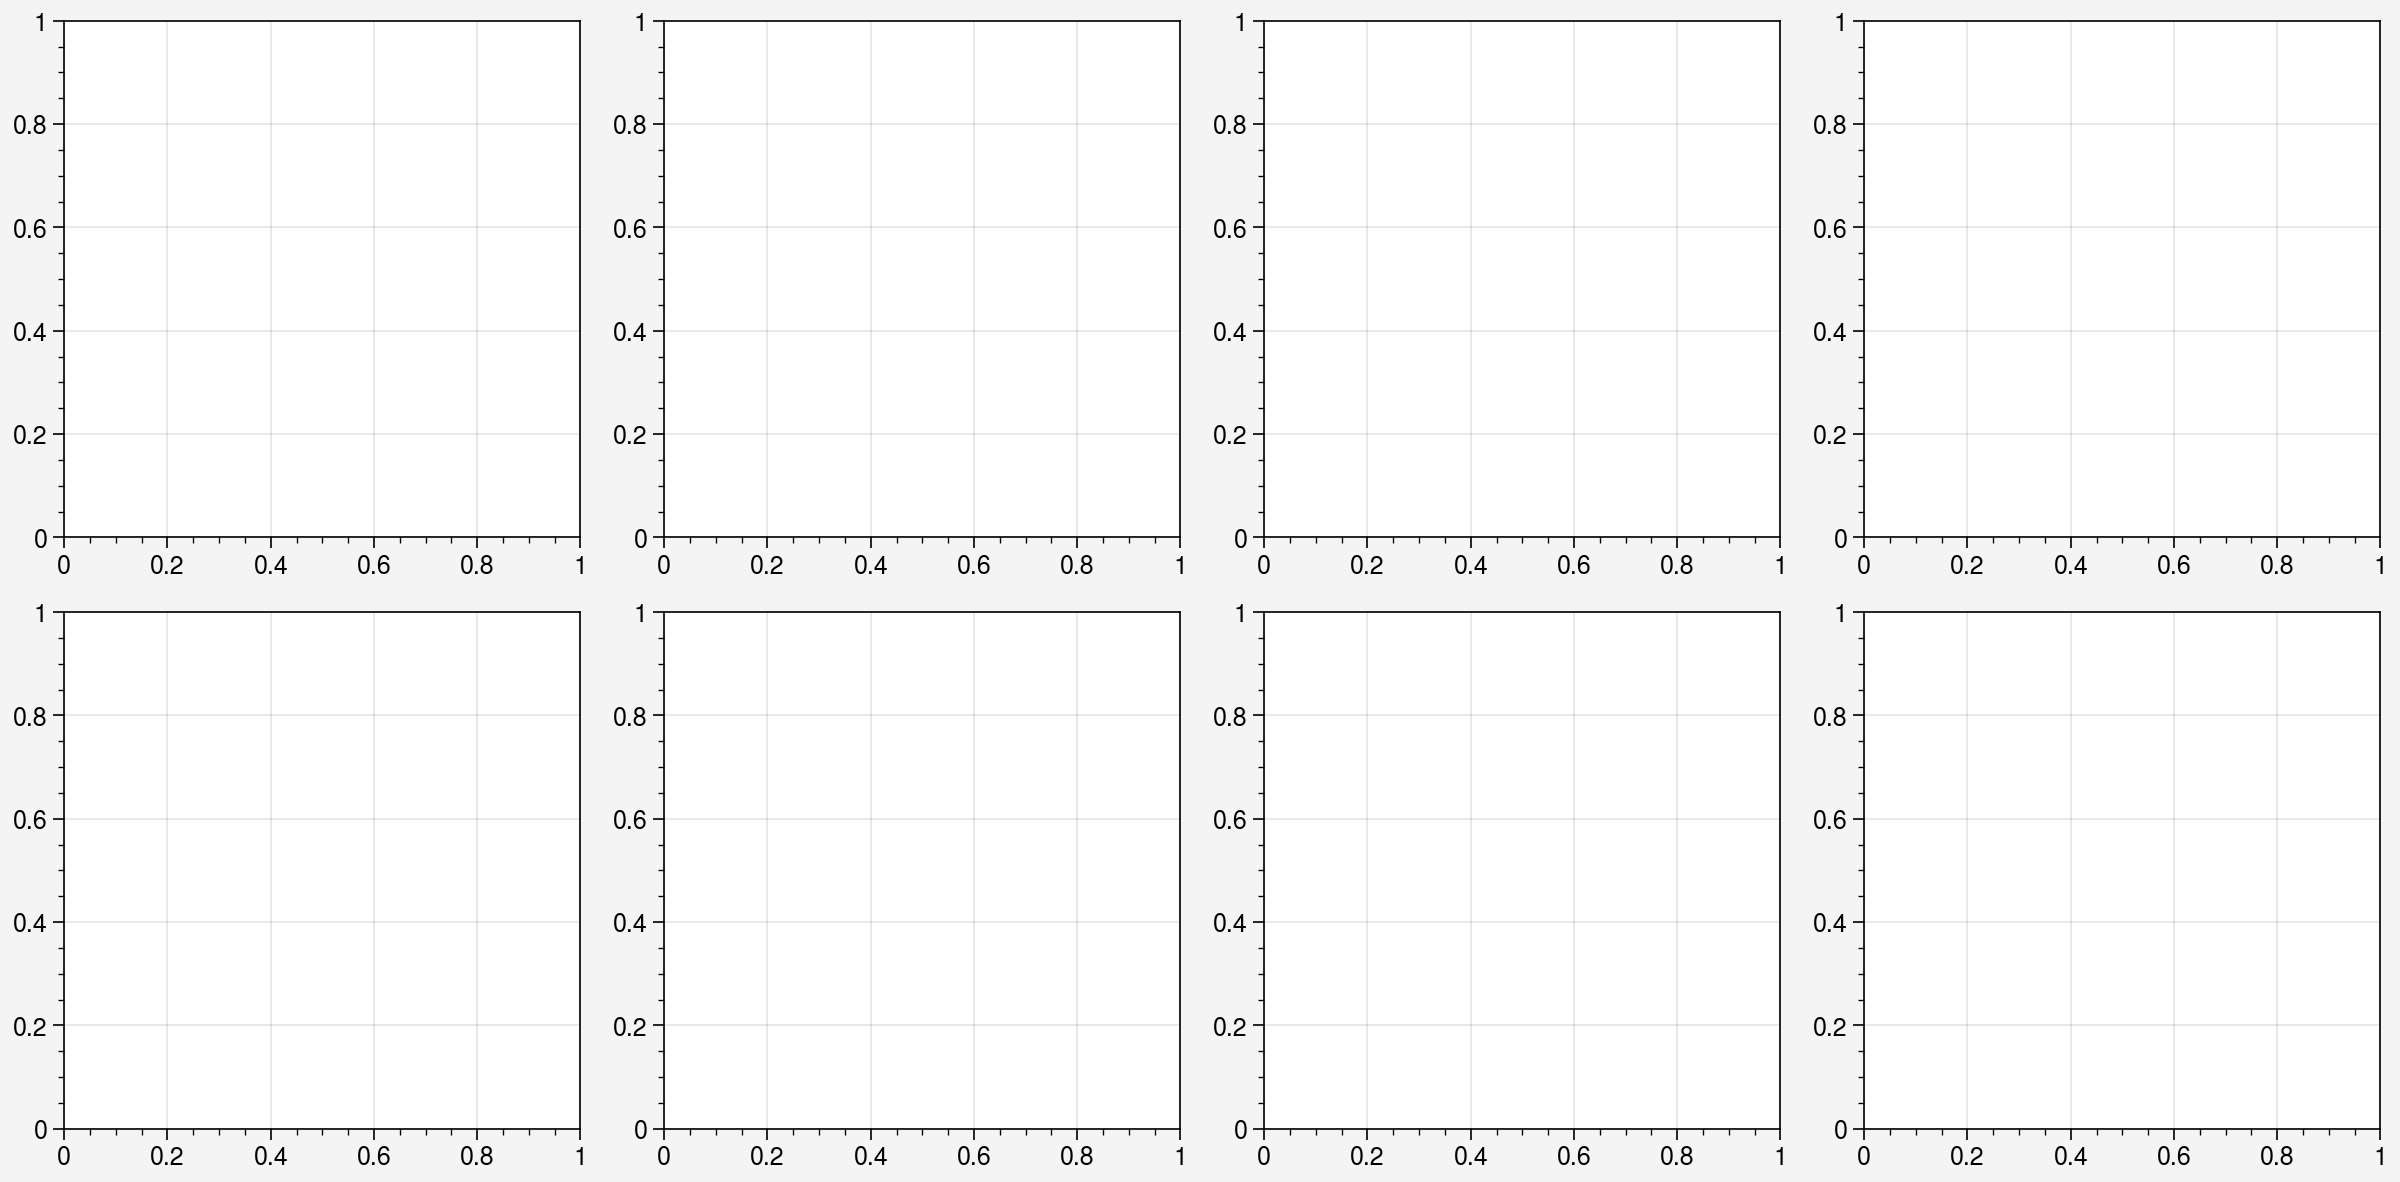

In [ ]:
fig, axs = plot.subplots(width=12,ncols=4,nrows=2,share=0)

ax = axs[0,0]
plot_xx = data_ensemble['t_est'].sel(quantile=0.5).values
runtime_xx = data_ensemble.attrs.get('runtime_minutes')

plot_yy = data_uncon['t_est'].sel(quantile=0.5).values
runtime_yy = data_uncon.attrs.get('runtime_minutes')

ax.scatter(plot_xx,plot_yy)
ax.format(
    xlabel='P50 t_est (ensem; hard con.)\n-->Desktop',
    ylabel='P50 t_est (direct; uncon.)',
    ultitle="lower = -1.8"
        +f"\nX runtime (min): {runtime_xx:.2f}"
        +f"\nY runtime (min): {runtime_yy:.2f}"
)

ax = axs[0,1]
plot_yy = data_uncon['t_est'].sel(quantile=0.5).values
runtime_yy = data_uncon.attrs.get('runtime_minutes')

plot_xx = data_hard['t_est'].sel(quantile=0.5).values
runtime_xx = data_hard.attrs.get('runtime_minutes')

ax.scatter(plot_xx,plot_yy)
ax.format(
    xlabel='P50 t_est (direct; hard con.)',
    ylabel='P50 t_est (direct; uncon.)',
    ultitle="lower = -1.8"
    +f"\nX runtime (min): {runtime_xx:.2f}"
    +f"\nY runtime (min): {runtime_yy:.2f}"
    
)

ax = axs[0,2]
plot_x = data_uncon['t_est'].sel(quantile=0.5).values
runtime_yy = data_uncon.attrs.get('runtime_minutes')

plot_xx = data_hard2['t_est'].sel(quantile=0.5).values
runtime_xx = data_hard2.attrs.get('runtime_minutes')

ax.scatter(plot_xx,plot_yy)
ax.format(
    xlabel='P50 t_est (direct; hard con.)',
    ylabel='P50 t_est (direct; uncon.)',
    ultitle="lower = -3.0"
    +f"\nX runtime (min): {runtime_xx:.2f}"
    +f"\nY untime (min): {runtime_yy:.2f}"
)

ax = axs[0,3]
plot_yy = data_uncon['t_est'].sel(quantile=0.5).values
runtime_yy = data_uncon.attrs.get('runtime_minutes')

plot_xx = data_hard3['t_est'].sel(quantile=0.5).values
runtime_xx = data_hard3.attrs.get('runtime_minutes')

ax.scatter(plot_xx,plot_yy)
ax.format(
    xlabel='P50 t_est (direct; hard con.)',
    ylabel='P50 t_est (direct; uncon.)',
    ultitle="lower = -5.0"
    +f"\nX runtime (min): {runtime_xx:.2f}"
    +f"\nY untime (min): {runtime_yy:.2f}"
)

ax = axs[1,0]

plot_xx = data_ensem2['t_est'].sel(quantile=0.5).values
runtime_xx = data_ensem2.attrs.get('runtime_minutes')

plot_yy = data_hard4['t_est'].sel(quantile=0.5).values
runtime_yy = data_hard4.attrs.get('runtime_minutes')

ax.scatter(plot_xx,plot_yy)
ax.format(
    xlabel='P50 t_est (ensem; hard con.)\n-->Desktop',
    ylabel='P50 t_est (direct; hard con.)\n-->Desktop',
    ultitle="lower = -1.8"
        +f"\nX runtime (min): {runtime_xx:.2f}"
        +f"\nY runtime (min): {runtime_yy:.2f}"
)


axs.format(xlim=(-5,40),ylim=(-5,40))
axs.plot([-5,40],[-5,40])

axs_idx = [1,2,3]
for idx in axs_idx:
    axs[1,idx].set_visible(False)
    
axs.format(abc=True,abcloc='lr',abcsize=20)

# Plotting Data

In [ ]:
fig, axs = plot.subplots(ncols=3,width=9,share=0)

ax = axs[0,0]
### coretop data
plot_x = coretop_df['sst']
plot_y = coretop_df['tex_median']
ax.scatter(plot_x,plot_y,m='.',c='gray5')


### culmeso data
grouped = culmeso_df.groupby('datatype')
for name, group in grouped:
    plot_x = group['SST']
    plot_y = group['TEX86']
    ax.scatter(plot_x,plot_y)
    
    
### calibration curve
xx = np.linspace(-5,50,100)
yy = predictTEXfromT(xx, method_name='schouten2002', temptype='sst')
ax.plot(xx,yy,c='red9')
ax.text(0.02,0.98,'Schouten2002',c='red9',
        fontsize=12,fontweight='bold',
        ha='left',va='top',
        transform=ax.transAxes)